# CancerMOBI-Bench README Code Verification

This notebook runs all Python code snippets from README.md to verify they work correctly.

## Setup: Load test data

Load survival_BRCA fold 0 with DNAm+mRNA+miRNA omics for testing all code snippets.

In [1]:
import pickle as pkl
import pandas as pd
import numpy as np

data_path = 'data/TCGA/survival_BRCA/survival_BRCA_CNV+DNAm+SNV+mRNA+miRNA.pkl'
with open(data_path, 'rb') as f:
    data = pkl.load(f)

fold = 0
omics = ['DNAm', 'mRNA', 'miRNA']

from utils import mod_mol_dict
mmdic = mod_mol_dict(data['X'].columns)
X = data['X'].loc[:, np.isin(mmdic['mods'], omics)]
y = data['y']

splits = data[f'fold{fold}']
X_trn = X.loc[splits == 'trn'].copy()
X_val = X.loc[splits == 'val'].copy()
X_tst = X.loc[splits == 'tst'].copy()

y_trn = (y.loc[splits == 'trn', 'T'] > np.median(y.loc[splits == 'trn', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_val = (y.loc[splits == 'val', 'T'] > np.median(y.loc[splits == 'val', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_tst = (y.loc[splits == 'tst', 'T'] > np.median(y.loc[splits == 'tst', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})

print(f"X_trn: {X_trn.shape}, X_val: {X_val.shape}, X_tst: {X_tst.shape}")
print(f"y_trn: {y_trn.shape}, y_val: {y_val.shape}, y_tst: {y_tst.shape}")
print(f"Omics: {omics}")
print(f"Sample X_trn columns: {list(X_trn.columns[:5])}")

X_trn: (413, 67944), X_val: (104, 67944), X_tst: (130, 67944)
y_trn: (413, 1), y_val: (104, 1), y_tst: (130, 1)
Omics: ['DNAm', 'mRNA', 'miRNA']
Sample X_trn columns: ['DNAm@cg00000108', 'DNAm@cg00000292', 'DNAm@cg00000658', 'DNAm@cg00000734', 'DNAm@cg00000924']


## Use Case 1: Benchmark your method

### Test 1: Example RF wrapper (README Step 1)

In [2]:
def run_method_custom(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    mode: int = 0,  # Mode 0: molecule-level output
):
    """Example wrapper for a random forest-based feature selection method."""
    from sklearn.ensemble import RandomForestClassifier
    import pandas as pd
    import numpy as np

    y_trn = y_train['label'].values

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train.values, y_trn)

    importances = model.feature_importances_

    ft_score = pd.DataFrame(
        index=X_train.columns,
        data={'score': importances}
    )

    return ft_score

ft_score = run_method_custom(X_trn, y_trn, X_val, y_val, X_tst, y_tst, mode=0)
print(f"ft_score shape: {ft_score.shape}")
ft_score.head(10)

ft_score shape: (67944, 1)


,score
DNAm@cg00000108,0.0
DNAm@cg00000292,0.0
DNAm@cg00000658,0.0
DNAm@cg00000734,0.0
DNAm@cg00000924,0.0
DNAm@cg00000957,0.0
DNAm@cg00001099,0.0
DNAm@cg00001349,0.0
DNAm@cg00001446,0.0
DNAm@cg00001582,0.0


### Test 2: run_benchmark() basic usage (README Step 2)

Running on 1 dataset, 1 omics combo, 2 folds for speed.

Running benchmark on dataset: survival_BRCA


----------------------------------------
Using omics types: ['DNAm', 'mRNA', 'miRNA']
----------------------------------------
Fold: 0
Number of DNAm features: 46859
Number of mRNA features: 19504
Number of miRNA features: 1581


Sample size: 647
Trn sample size: (array(['long', 'short'], dtype=object), array([206, 207]))
Val sample size: (array(['long', 'short'], dtype=object), array([52, 52]))
Tst sample size: (array(['long', 'short'], dtype=object), array([65, 65]))
Scaling data using standard scaling...



Running custom method...



----------------------------------------
Fold: 1
Number of DNAm features: 46859
Number of mRNA features: 19504
Number of miRNA features: 1581


...

Gene ranking size: 26520
Biomarker set size: 14



-----------------------------------------
Evaluating accuracy for survival_BRCA ...
omics comb.: DNAm+mRNA+miRNA 	Fold: 1



Gene ranking size: 26520
Biomarker set size: 14



-----------------------------------------
Evaluating stability for survival_BRCA ...


Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 2 for task survival_BRCA, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 3 for task survival_BRCA, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 4 for task survival_BRCA, as no results scores are found.

Benchmarking completed. Results saved to: ./result/test_readme/


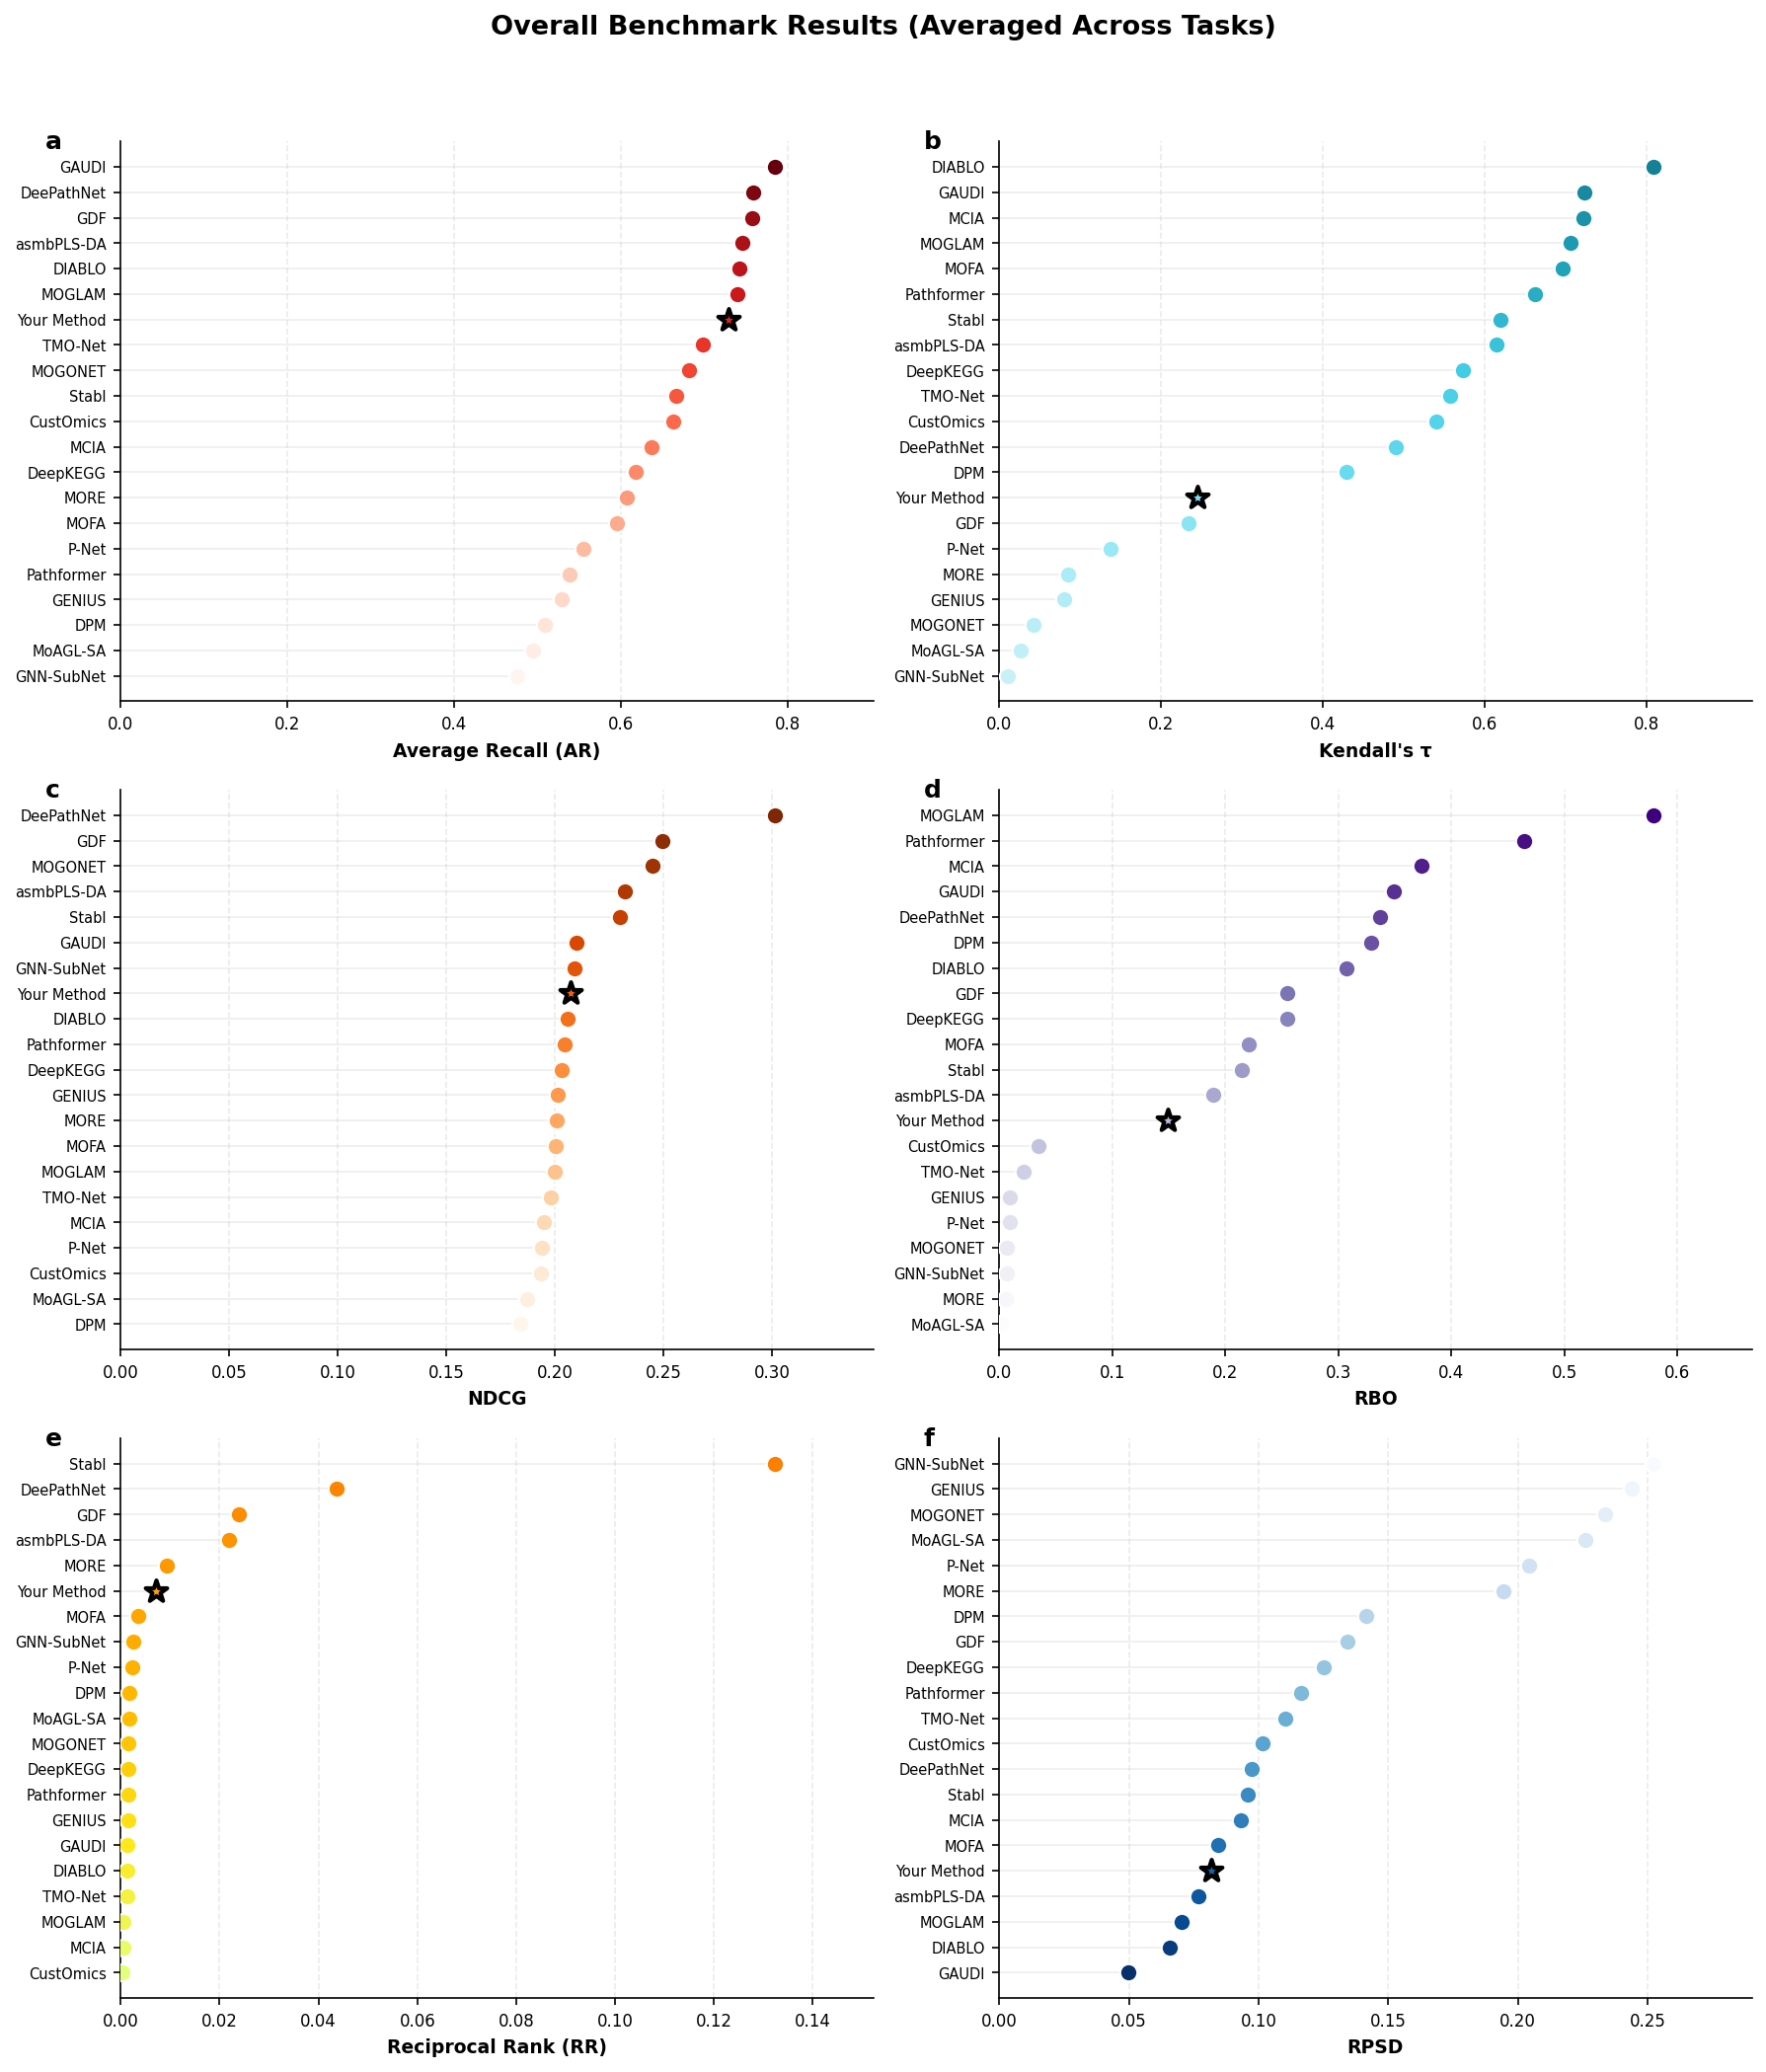

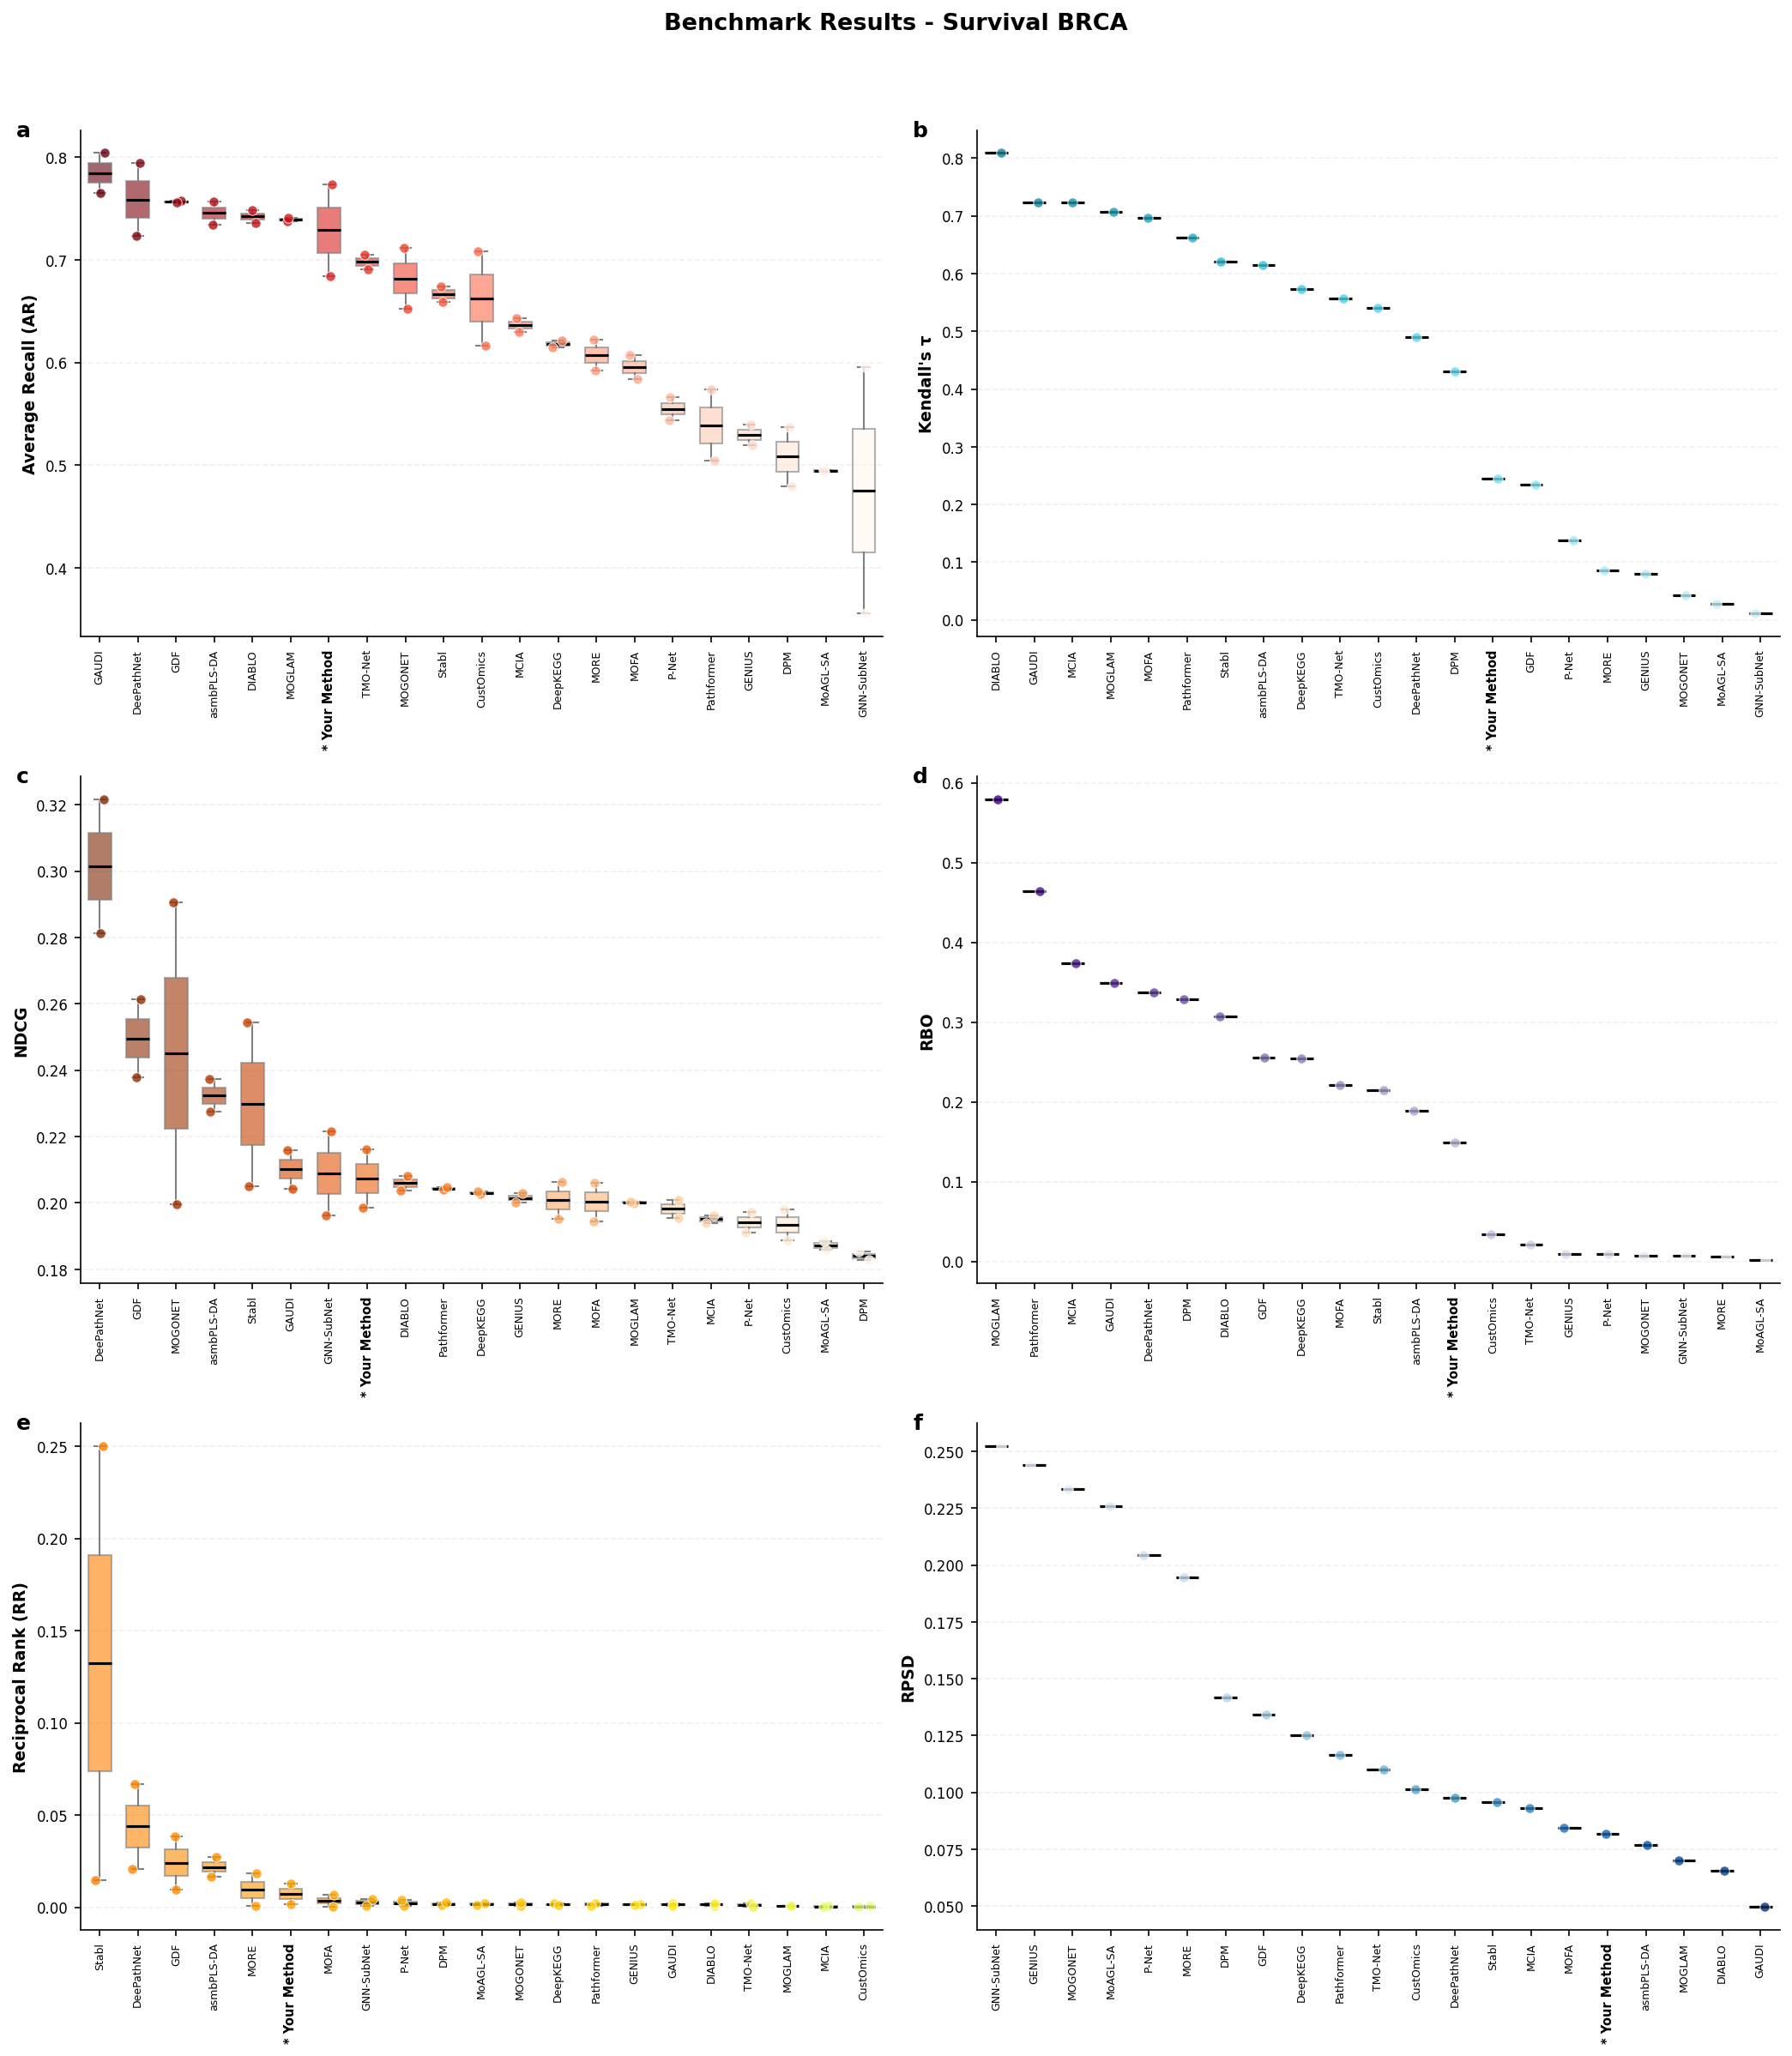

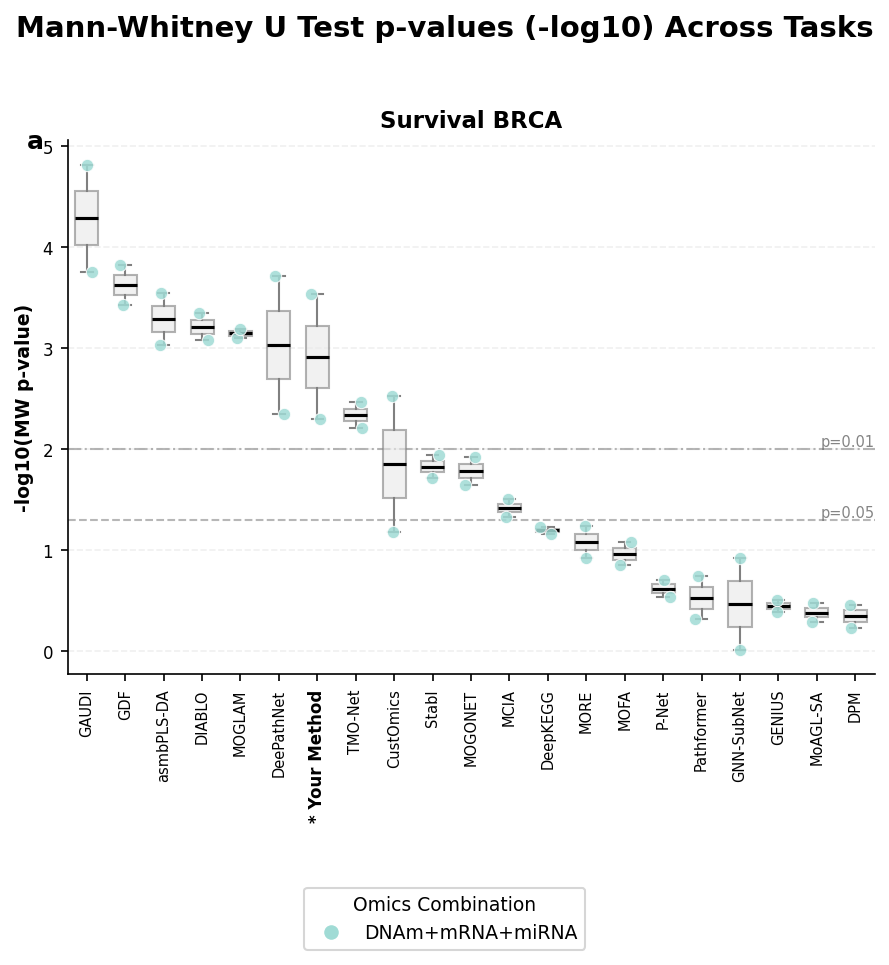

acc_res keys: ['NDCG', 'RR', 'AR', 'MW_pval']
sta_res keys: ['Kendall_tau', 'RBO', 'PSD']

NDCG values: {('survival_BRCA', 'DNAm+mRNA+miRNA', 0): np.float64(0.21620224152455086), ('survival_BRCA', 'DNAm+mRNA+miRNA', 1): np.float64(0.1985351667393597)}
RR values: {('survival_BRCA', 'DNAm+mRNA+miRNA', 0): np.float64(0.012658227848101266), ('survival_BRCA', 'DNAm+mRNA+miRNA', 1): np.float64(0.0014064697609001407)}
AR values: {('survival_BRCA', 'DNAm+mRNA+miRNA', 0): np.float64(0.7738256841198018), ('survival_BRCA', 'DNAm+mRNA+miRNA', 1): np.float64(0.6837804352510236)}


In [3]:
from benchmark_pipeline import run_benchmark

acc_res, sta_res = run_benchmark(
    run_method_custom_func=run_method_custom,
    datasets_to_run=[0],
    omics_types=['DNAm', 'mRNA', 'miRNA'],
    fold_to_run=[0, 1],
    res_save_path='./result/test_readme/',
)

print("acc_res keys:", list(acc_res.keys()))
print("sta_res keys:", list(sta_res.keys()))
print("\nNDCG values:", acc_res['NDCG'])
print("RR values:", acc_res['RR'])
print("AR values:", acc_res['AR'])

### Test 3: Configuration options (README config block)

Testing with 2 datasets, 3 folds, specific options.

Running benchmark on dataset: survival_BRCA


----------------------------------------
Using omics types: ['DNAm', 'mRNA', 'miRNA']
----------------------------------------
Fold: 0
Number of DNAm features: 46859
Number of mRNA features: 19504
Number of miRNA features: 1581


Sample size: 647
Trn sample size: (array(['long', 'short'], dtype=object), array([206, 207]))
Val sample size: (array(['long', 'short'], dtype=object), array([52, 52]))
Tst sample size: (array(['long', 'short'], dtype=object), array([65, 65]))
Scaling data using standard scaling...



Running custom method...



----------------------------------------
Fold: 1
Number of DNAm features: 46859
Number of mRNA features: 19504
Number of miRNA features: 1581


...

Gene ranking size: 26513
Biomarker set size: 14

-----------------------------------------
Evaluating stability for survival_BRCA ...


Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 3 for task survival_BRCA, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 4 for task survival_BRCA, as no results scores are found.



-----------------------------------------
Evaluating stability for survival_LUAD ...


Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 3 for task survival_LUAD, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 4 for task survival_LUAD, as no results scores are found.



Benchmarking completed. Results saved to: ./result/test_readme_config/


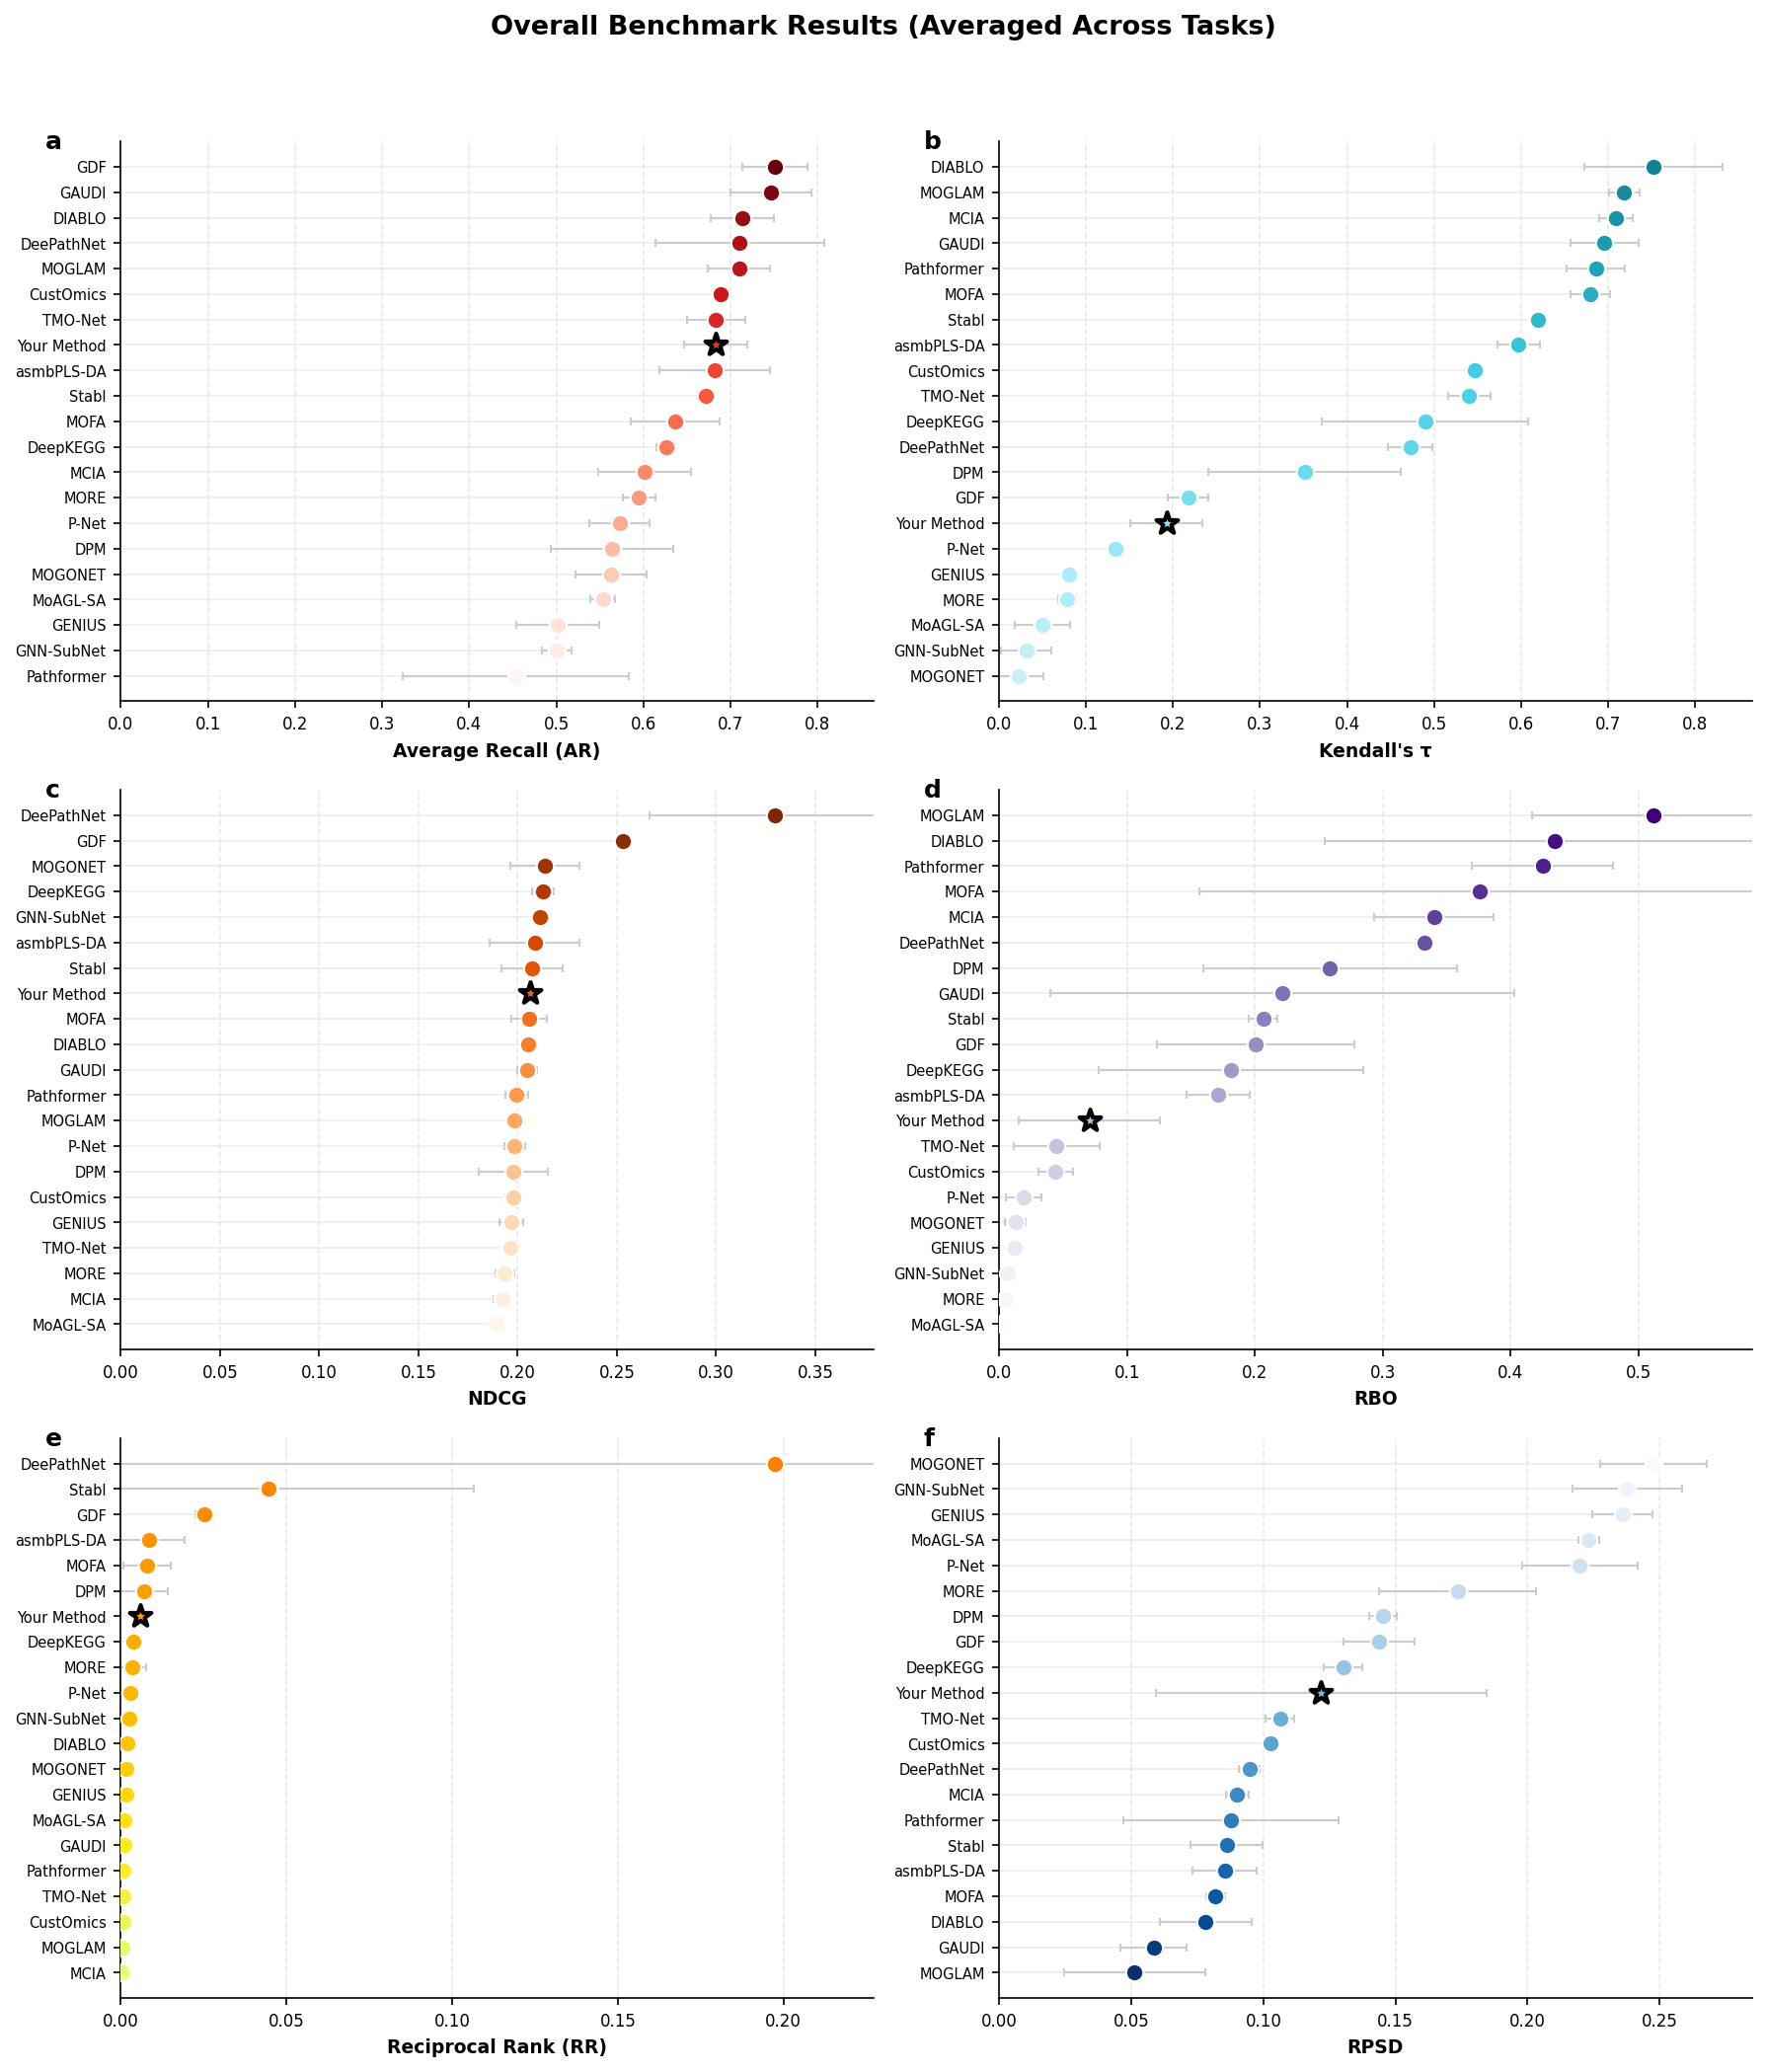

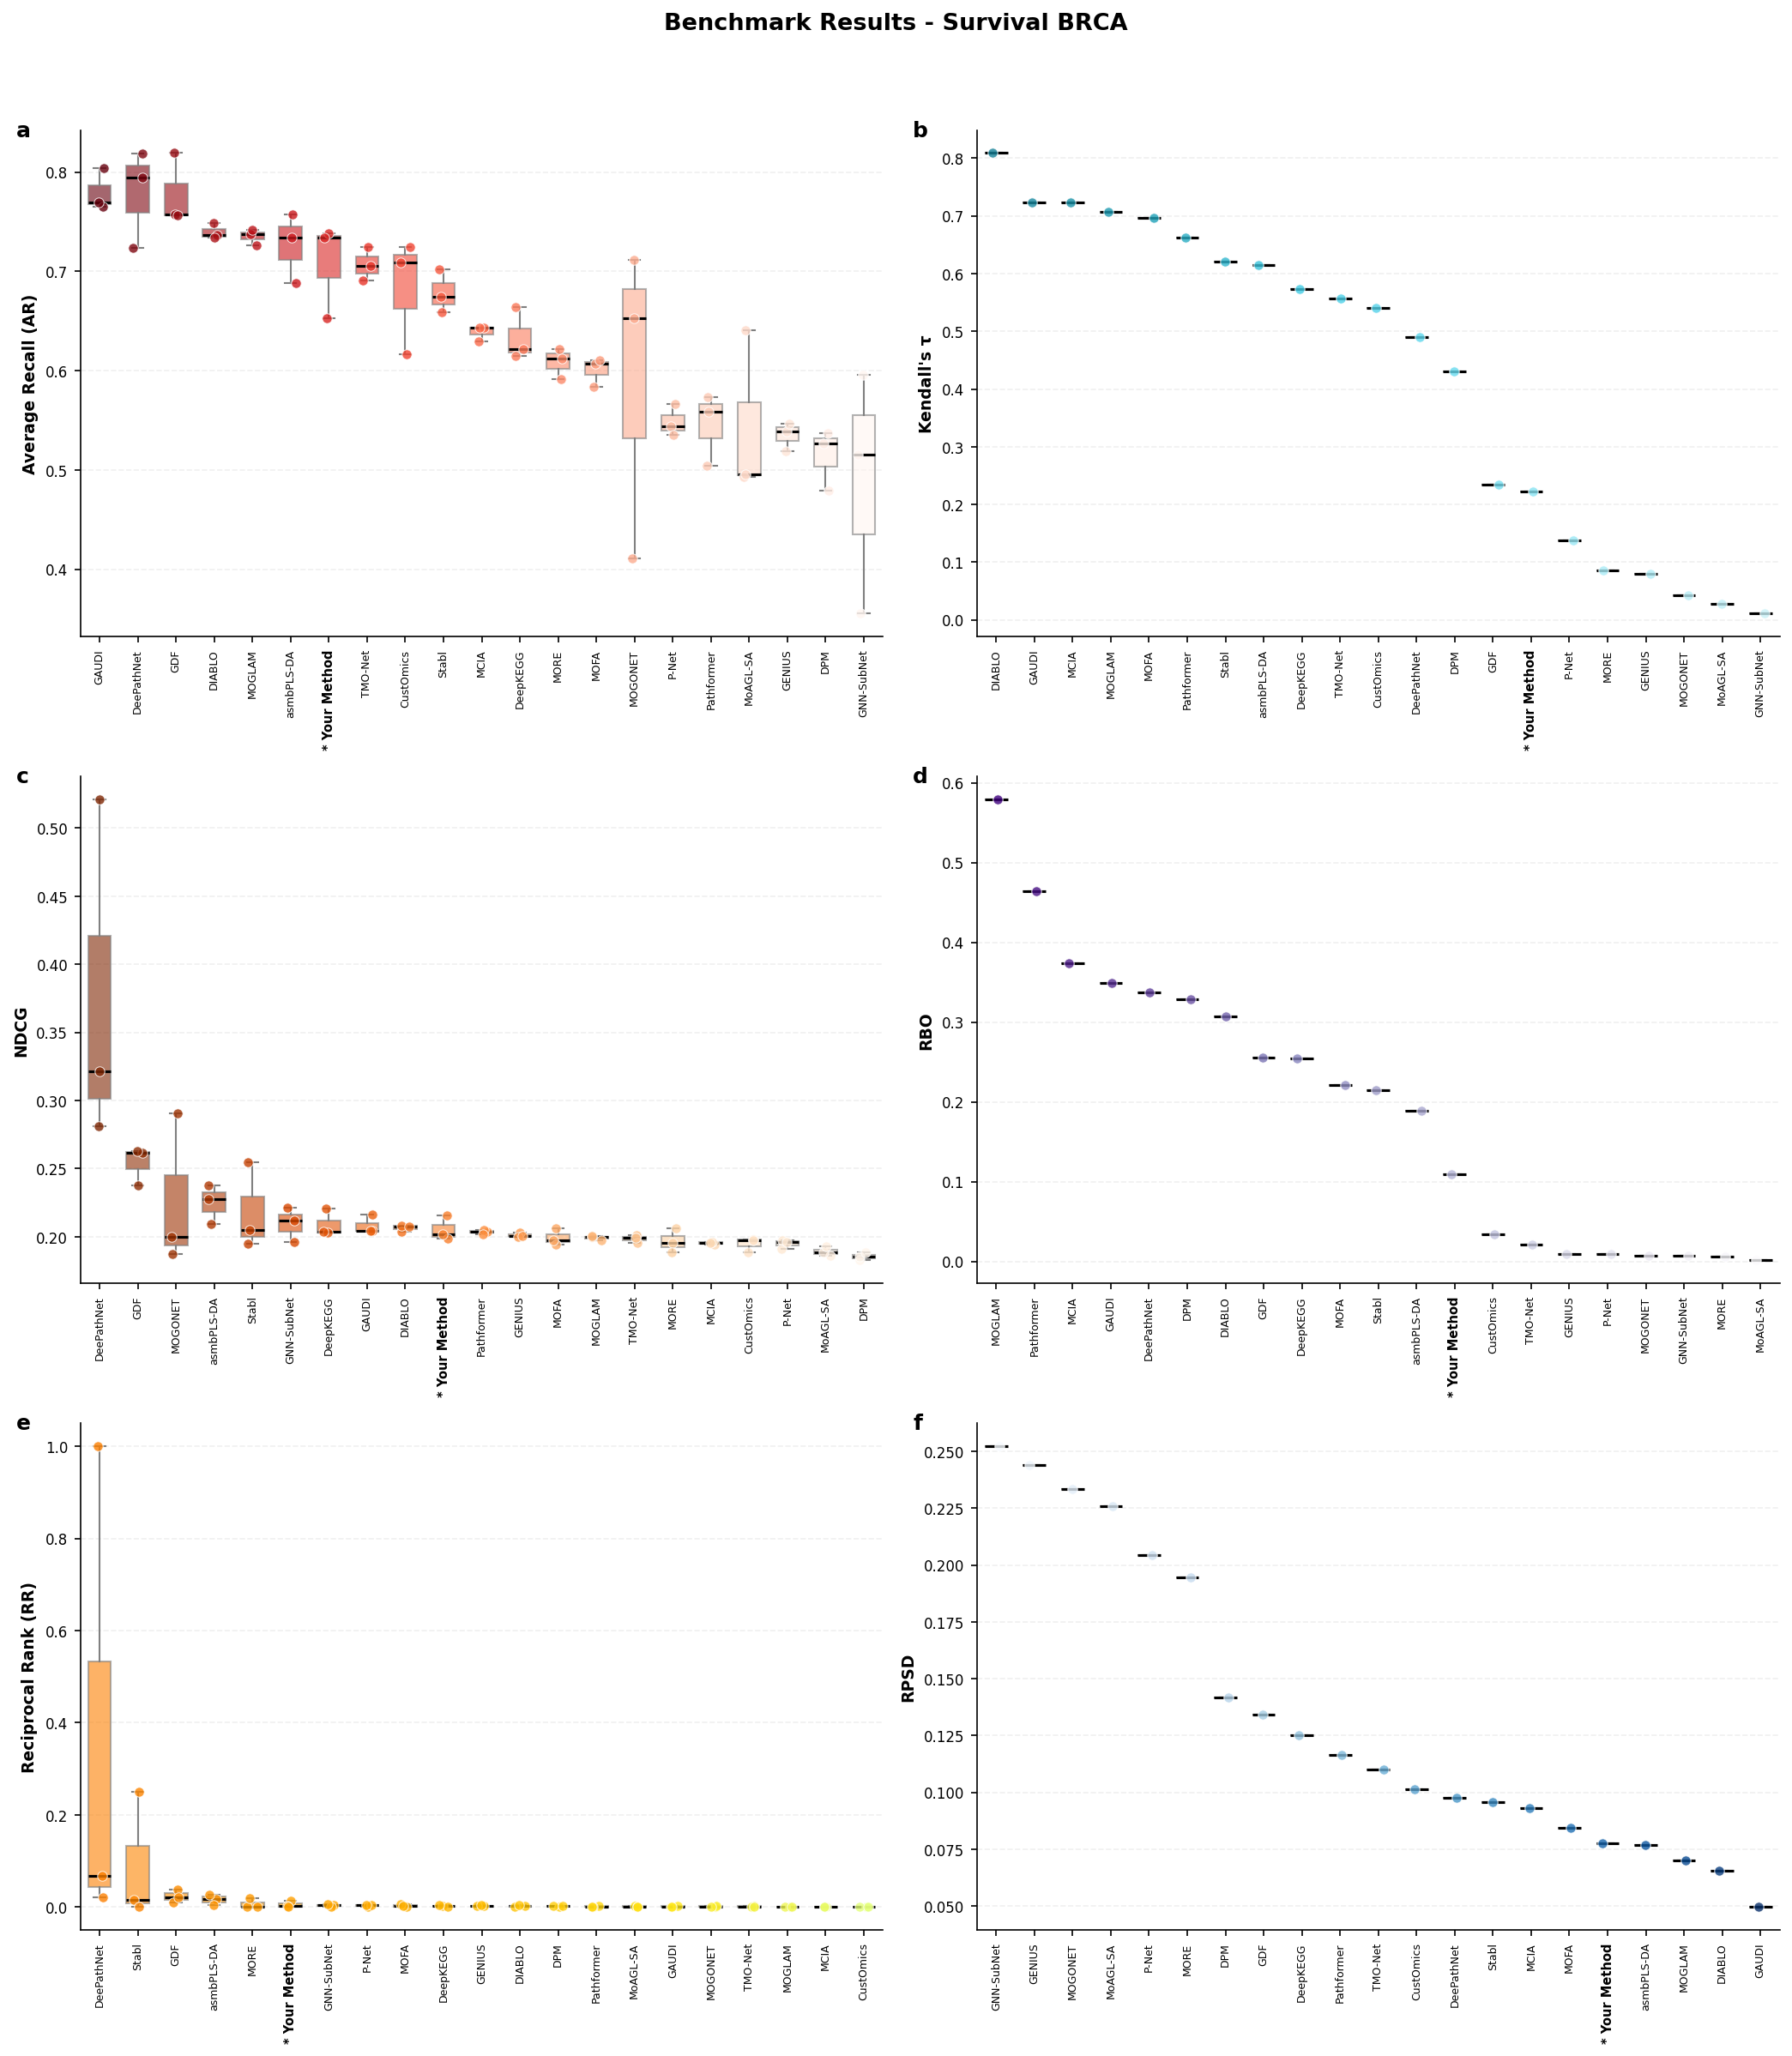

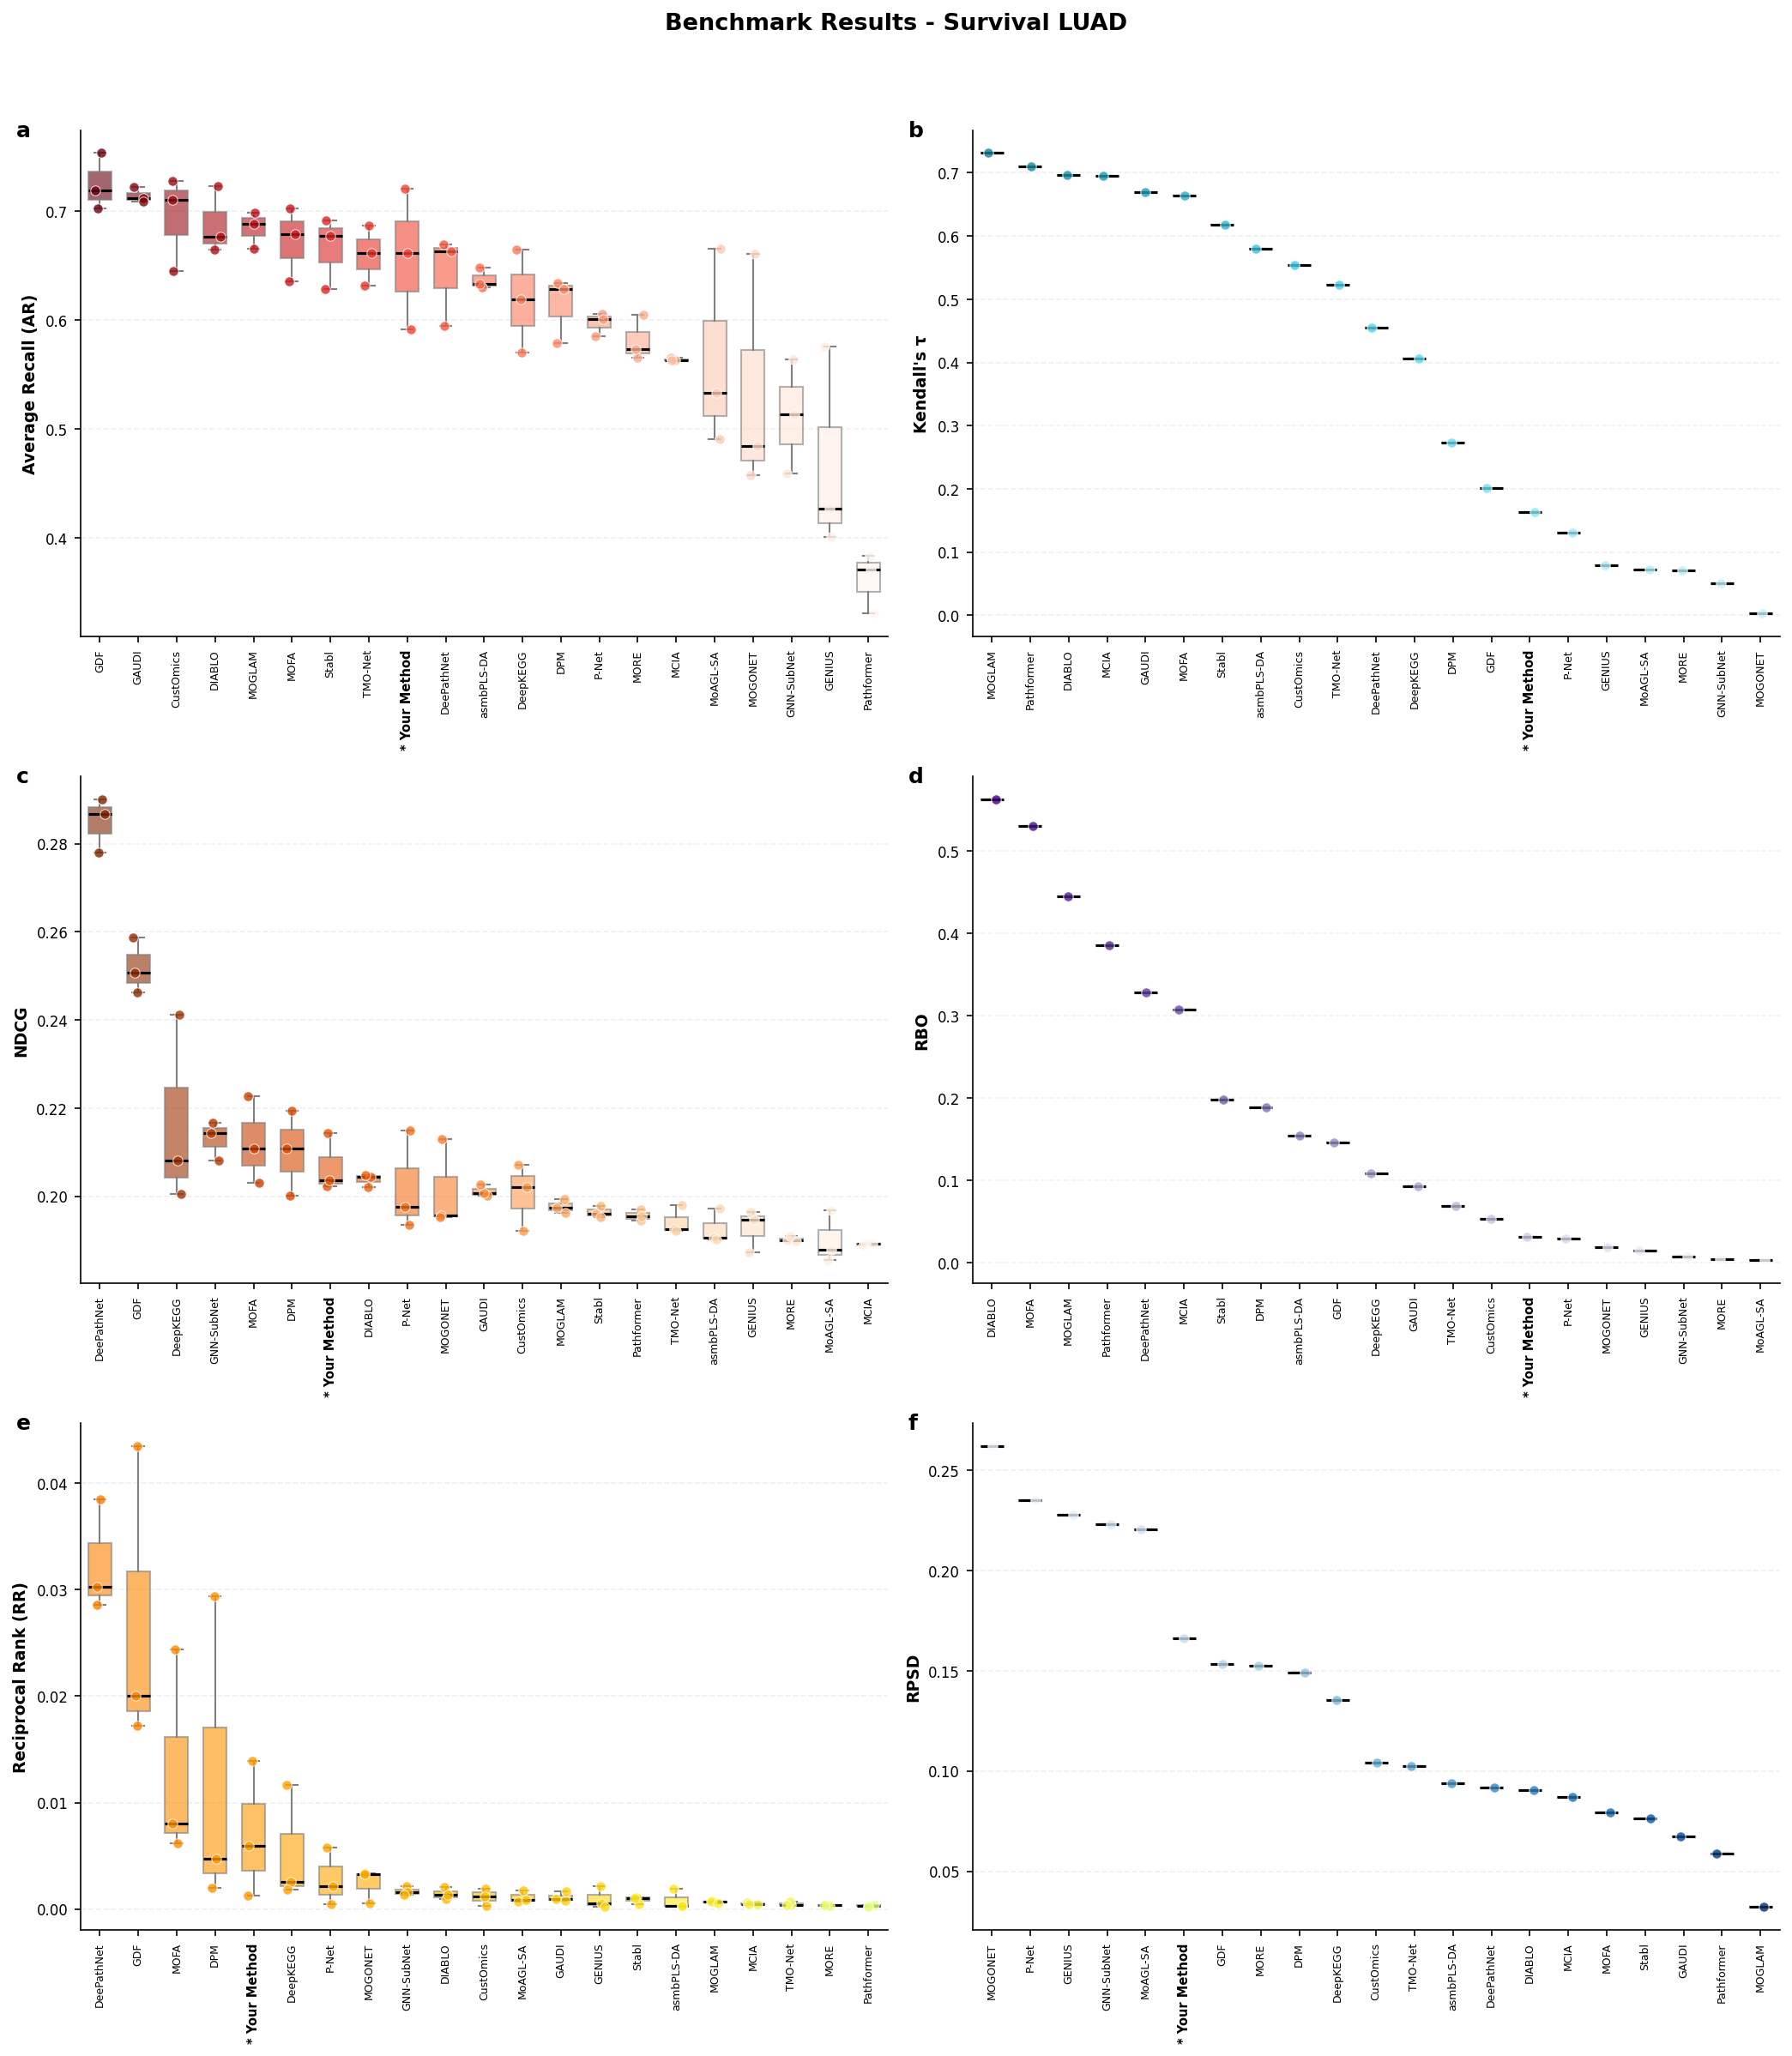

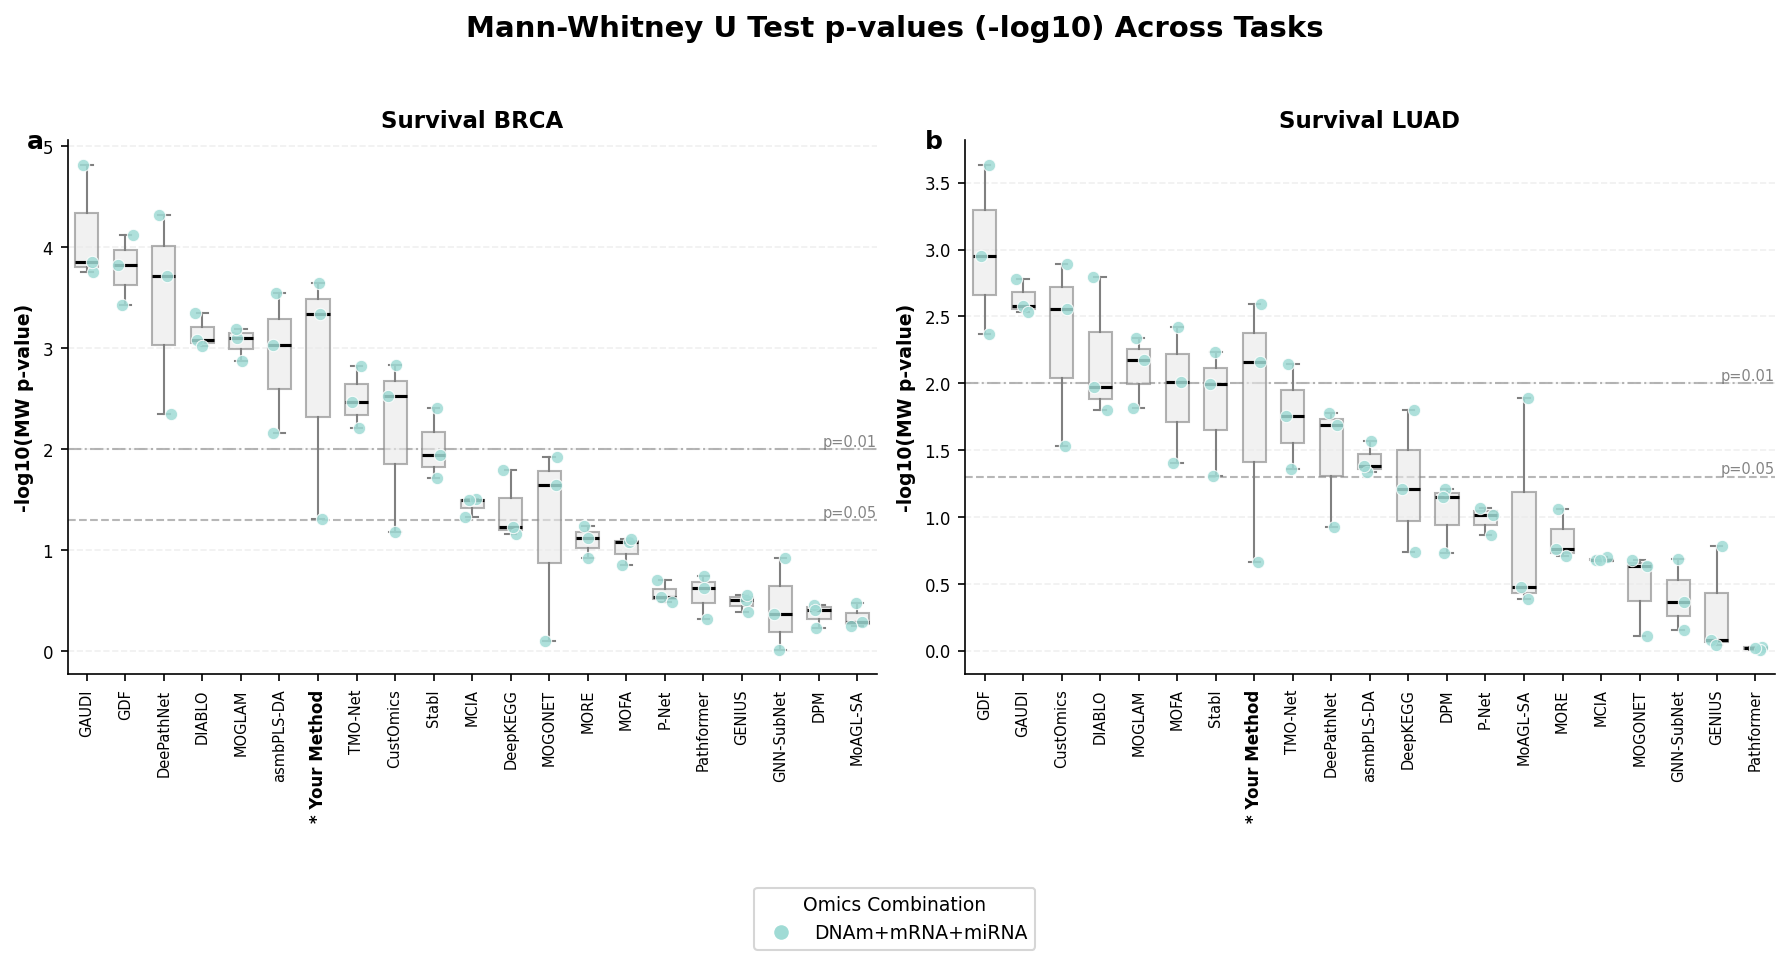

Number of NDCG entries: 6 (expected: 2 datasets x 1 omics x 3 folds = 6)
NDCG values: {('survival_BRCA', 'DNAm+mRNA+miRNA', 0): np.float64(0.21591900272255105), ('survival_BRCA', 'DNAm+mRNA+miRNA', 1): np.float64(0.19841855849665113), ('survival_BRCA', 'DNAm+mRNA+miRNA', 2): np.float64(0.20189533482449504), ('survival_LUAD', 'DNAm+mRNA+miRNA', 0): np.float64(0.20221625456828826), ('survival_LUAD', 'DNAm+mRNA+miRNA', 1): np.float64(0.20352195992933655), ('survival_LUAD', 'DNAm+mRNA+miRNA', 2): np.float64(0.21422779333449507)}


In [4]:
acc_res, sta_res = run_benchmark(
    run_method_custom_func=run_method_custom,

    # Select specific dataset(s) - default: all 5 datasets (see table below)
    datasets_to_run=[0, 1],  # Run on BRCA and LUAD survival tasks
    # Or use string names:
    # datasets_to_run=['survival_BRCA', 'survival_LUAD'],

    # Select specific omics combination(s) - default: all 6 tri-omics combinations (with mRNA included)
    omics_types=['DNAm', 'mRNA', 'miRNA'],  # Single combination as a list

    # Select specific fold(s) - default: all 5 folds (0-4)
    fold_to_run=[0, 1, 2],  # Run only folds 0, 1, 2

    # Survival label handling - default: 'binary'
    surv_op='binary',   # Binary labels split at median survival time

    # Data scaling method - default: 'standard'
    scaling='standard',  # Z-score normalization

    # Output path - default: './result/'
    res_save_path='./result/test_readme_config/',
)

print(f"Number of NDCG entries: {len(acc_res['NDCG'])} (expected: 2 datasets x 1 omics x 3 folds = 6)")
print(f"NDCG values: {acc_res['NDCG']}")

### Test 4: String dataset names

Testing that string names work for `datasets_to_run`.

Running benchmark on dataset: survival_BRCA


----------------------------------------
Using omics types: ['DNAm', 'mRNA', 'miRNA']
----------------------------------------
Fold: 0
Number of DNAm features: 46859
Number of mRNA features: 19504
Number of miRNA features: 1581


Sample size: 647
Trn sample size: (array(['long', 'short'], dtype=object), array([206, 207]))
Val sample size: (array(['long', 'short'], dtype=object), array([52, 52]))
Tst sample size: (array(['long', 'short'], dtype=object), array([65, 65]))
Scaling data using standard scaling...



Running custom method...



----------------------------------------
Fold: 1
Skipping fold 1 as it is not equal to fold_to_run 0.
----------------------------------------
Fold: 2
Skipping fold 2 as it is not equal to fold_to_run 0.
----------------------------------------
Fold: 3
Skipping fold 3 as it is not equal to fold_to_run 0.
----------------------------------------
Fold: 4
Skipping fold 4 as it is not equal to fold_to_run 0.

Evaluating benchmark results...

-----------------------------------------
Evaluating accuracy for survival_BRCA ...
omics comb.: DNAm+mRNA+miRNA 	Fold: 0



Gene ranking size: 26520
Biomarker set size: 14



-----------------------------------------
Evaluating stability for survival_BRCA ...


Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 1 for task survival_BRCA, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 2 for task survival_BRCA, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 3 for task survival_BRCA, as no results scores are found.
Skipping omics_comb ['DNAm', 'mRNA', 'miRNA'] - fold 4 for task survival_BRCA, as no results scores are found.

Benchmarking completed. Results saved to: ./result/test_readme_strname/


/home/athan.li/projects/eval_bk_github/CancerMOBI-Bench/utils.py:824: RuntimeWarning: Mean of empty slice
  your_method_sta[metric_key][task] = float(np.nanmean(np.asarray(your_method_sta[metric_key][task], dtype=float)))


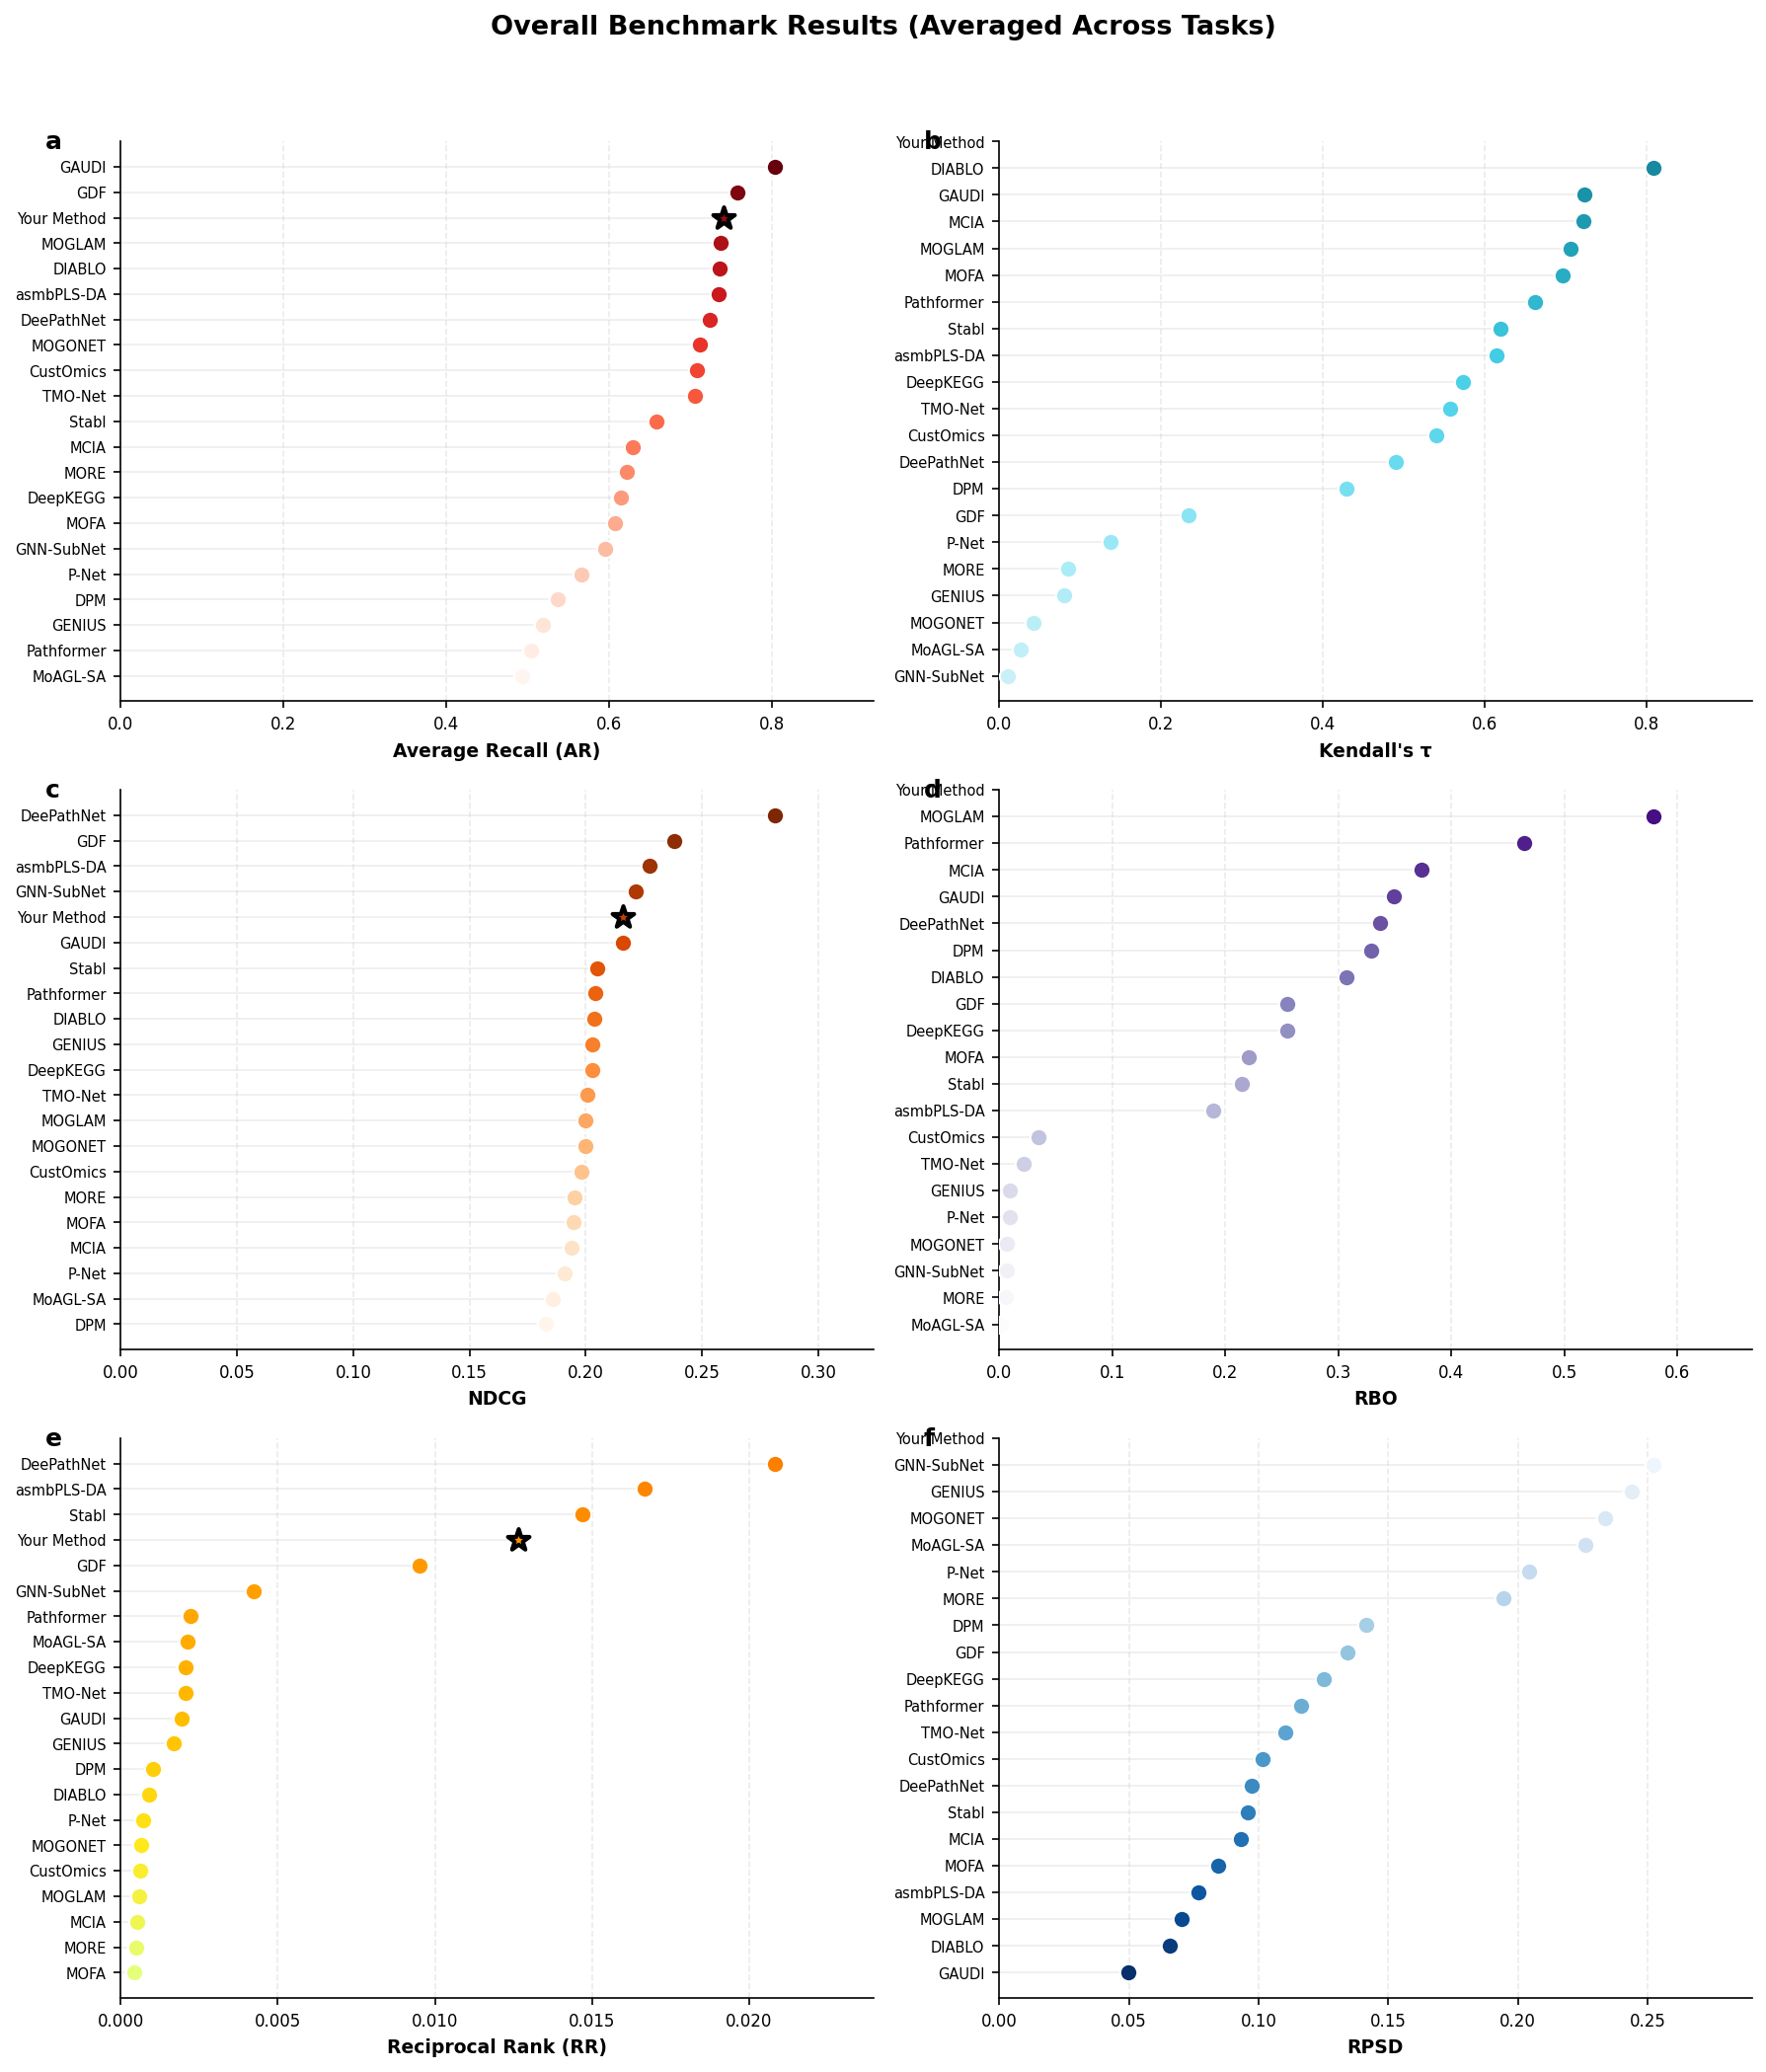

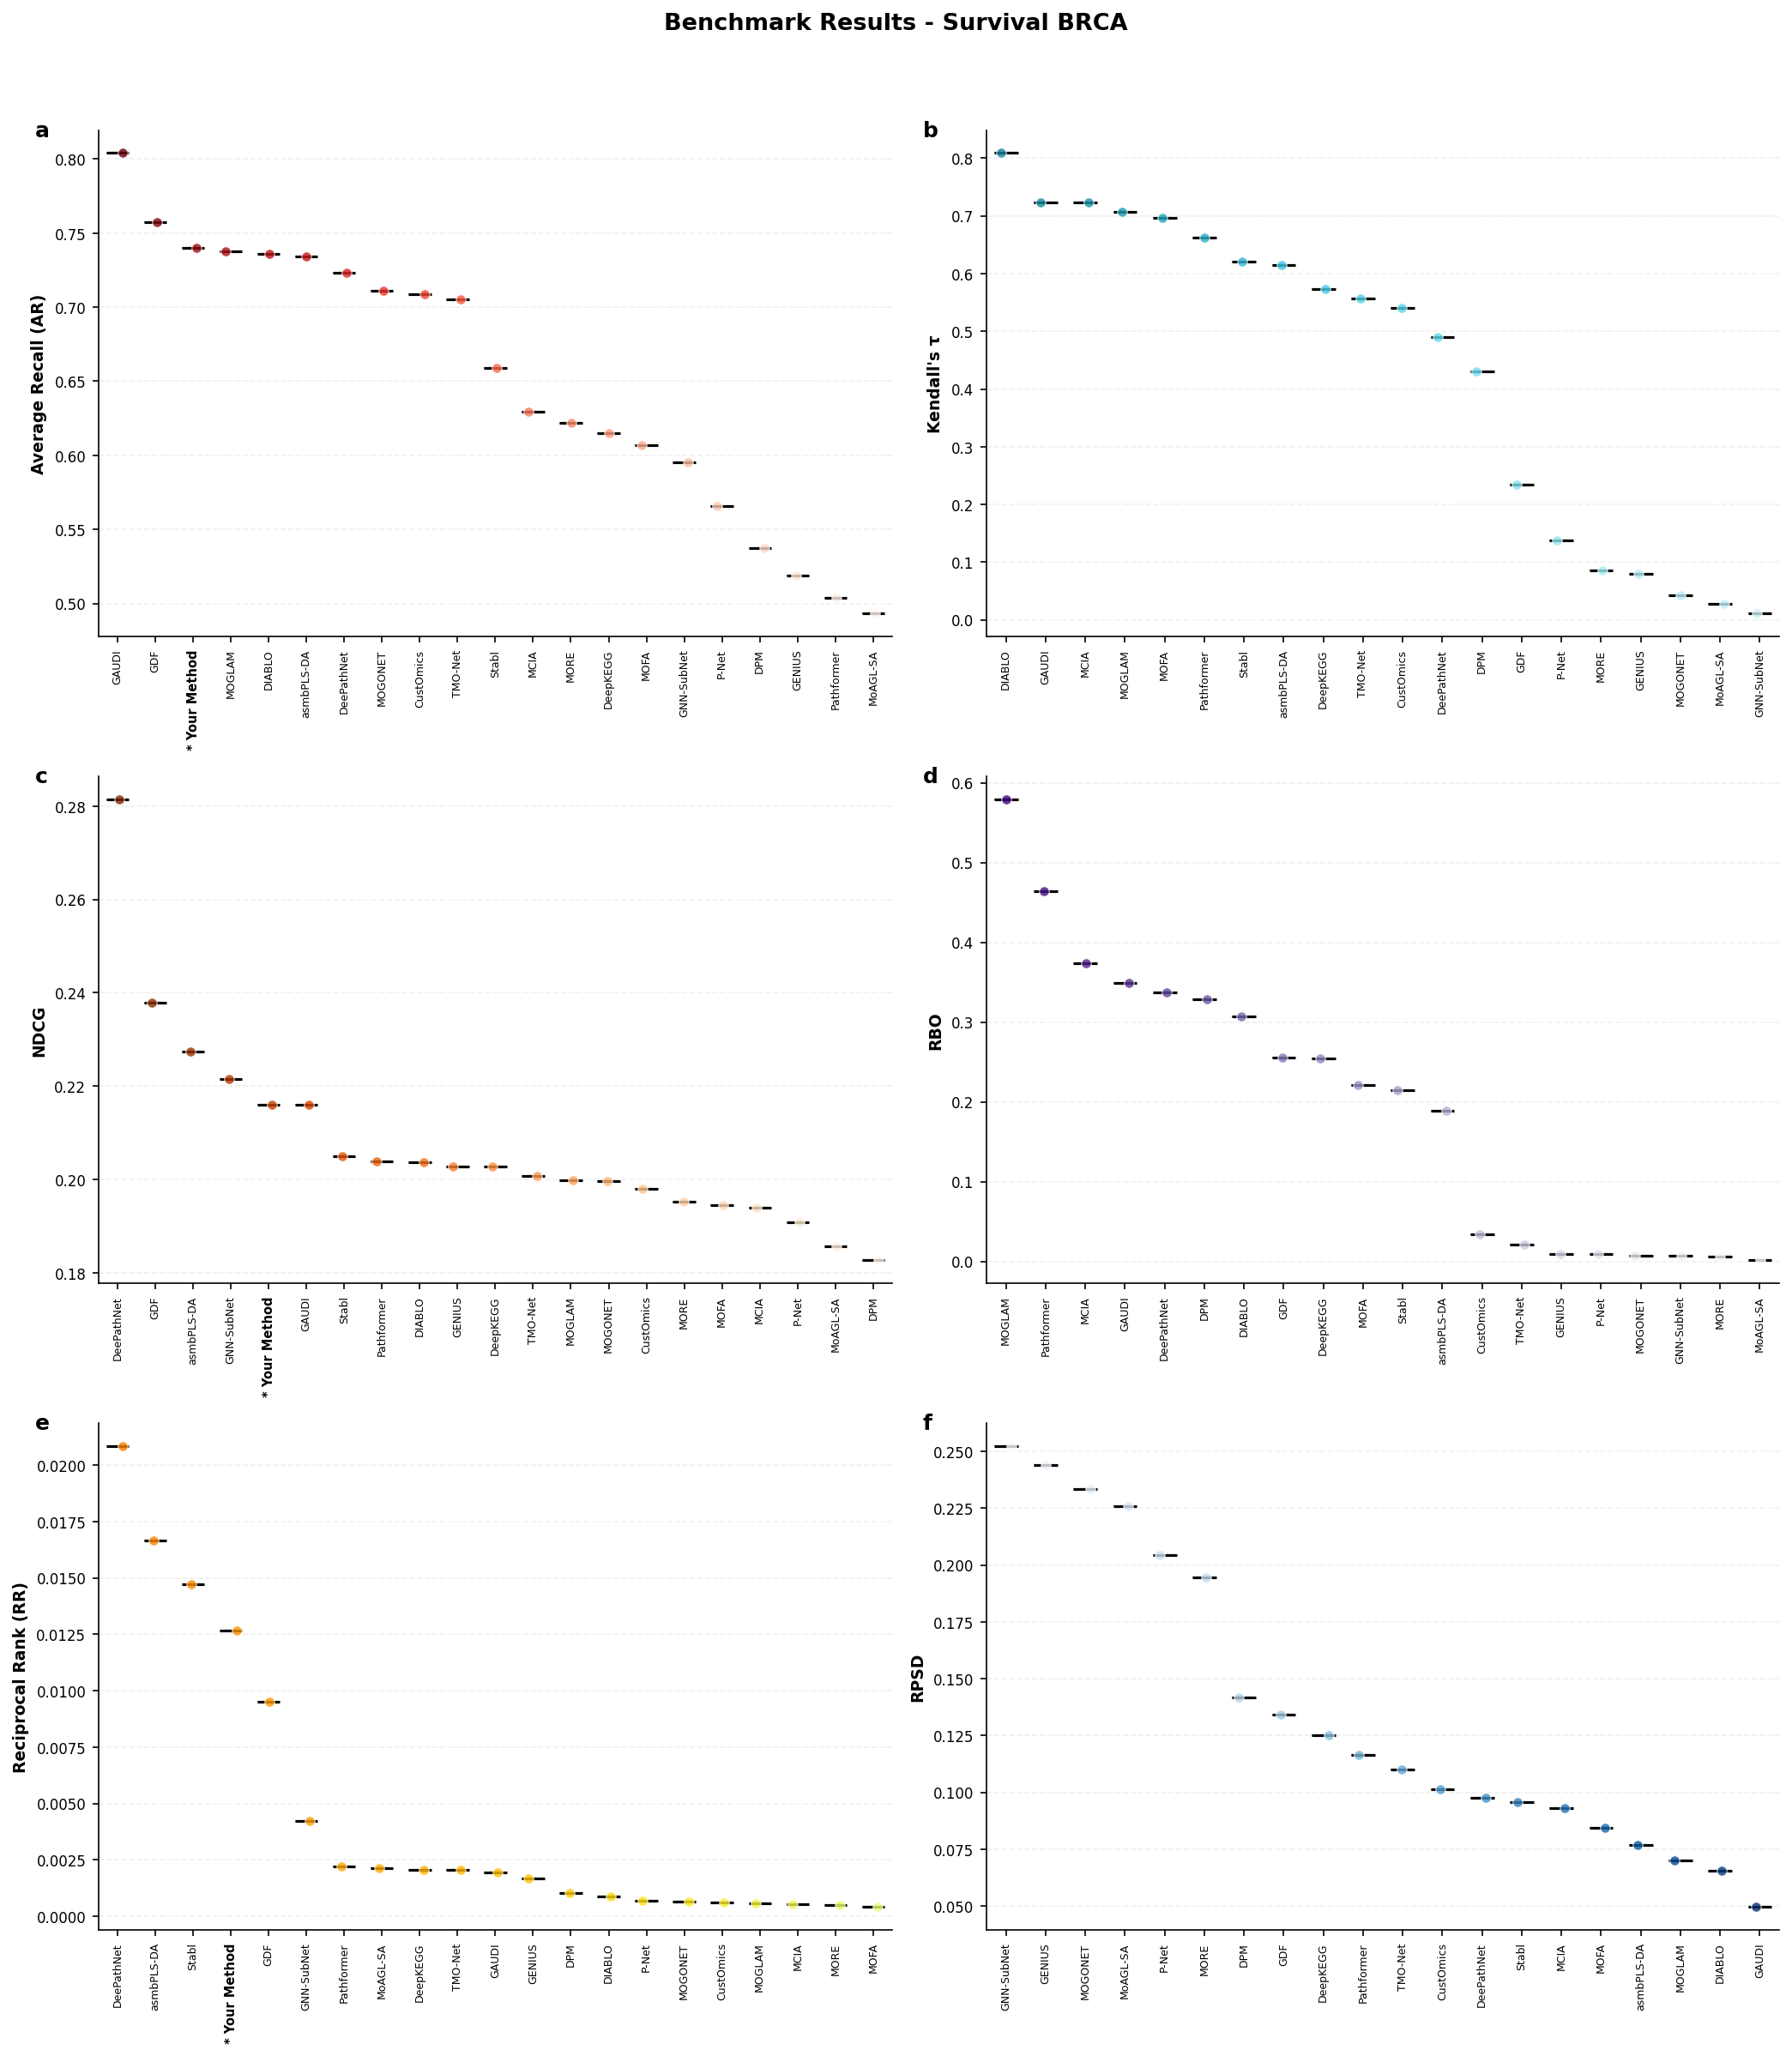

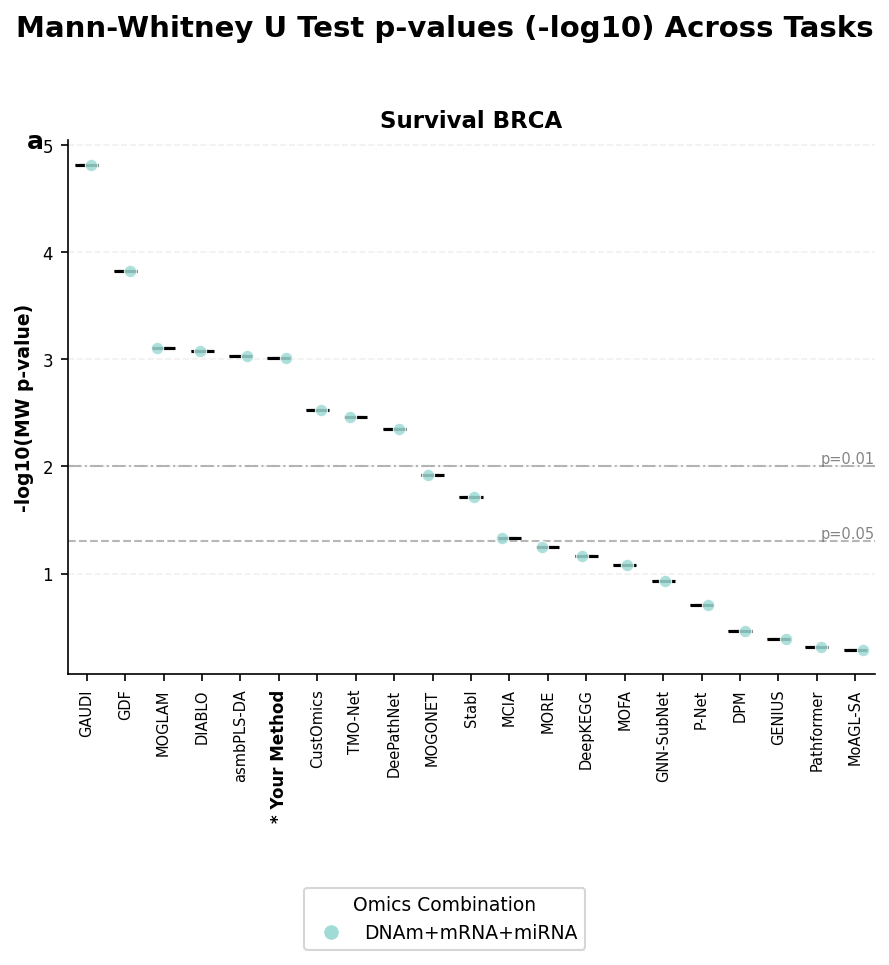

NDCG: {('survival_BRCA', 'DNAm+mRNA+miRNA', 0): np.float64(0.2159897036518499)}


In [5]:
acc_res, sta_res = run_benchmark(
    run_method_custom_func=run_method_custom,
    datasets_to_run=['survival_BRCA'],
    omics_types=['DNAm', 'mRNA', 'miRNA'],
    fold_to_run=0,
    res_save_path='./result/test_readme_strname/',
)

print(f"NDCG: {acc_res['NDCG']}")

## Use Case 2: Discover candidate biomarkers

### Test 5: run_method('DIABLO') (README Step 1)

In [6]:
from run_method import run_method

# Statistical/ML method (needs train + test)
ft_score = run_method('DIABLO', X_train=X_trn, y_train=y_trn,
                      X_test=X_tst, y_test=y_tst)

print(f"ft_score shape: {ft_score.shape}")
ft_score.head(10)

R[write to console]: Loading required package: MASS



R[write to console]: Loading required package: lattice



R[write to console]: Loading required package: ggplot2



R[write to console]: 
Loaded mixOmics 6.28.0
Thank you for using mixOmics!
Tutorials: http://mixomics.org
Bookdown vignette: https://mixomicsteam.github.io/Bookdown
Questions, issues: Follow the prompts at http://mixomics.org/contact-us
Cite us:  citation('mixOmics')




R[write to console]: 
Attaching package: ‘caret’




R[write to console]: The following objects are masked from ‘package:mixOmics’:

    nearZeroVar, plsda, splsda




DIABLO (training time + BK identification time) running time: 90.05 s
AUC-ROC:        0.4388
AUCPR:          0.4680
F1:  0.4444
Precision:  0.4286
Recall:     0.4615
MCC: -0.1543
Accuracy:       0.4231
Performance: {'acc': 0.4230769230769231, 'f1': np.float64(0.4444444444444444), 'precision': np.float64(0.42857142857142855), 'recall': np.float64(0.46153846153846156), 'f1_weighted': None, 'f1_macro': None, 'roc_auc': np.float64(0.43881656804733726), 'aucpr': np.float64(0.4679623534117674), 'mcc': np.float64(-0.1543033499620919), 'balanced_acc': np.float64(0.42307692307692313), 'auroc': np.float64(0.43881656804733726), 'aupr': np.float64(0.4679623534117674)}


ft_score shape: (67944, 1)


,score
DNAm@cg00000108,64377
DNAm@cg00000292,29223
DNAm@cg00000658,65910
DNAm@cg00000734,64652
DNAm@cg00000924,62991
DNAm@cg00000957,66460
DNAm@cg00001099,18421
DNAm@cg00001349,64927
DNAm@cg00001446,54861
DNAm@cg00001582,56704


### Test 6: run_method('DeePathNet') (README Step 1 - DL method)

In [7]:
# Deep learning method (needs train + val + test + GPU)
ft_score = run_method('DeePathNet', X_train=X_trn, y_train=y_trn,
                      X_val=X_val, y_val=y_val,
                      X_test=X_tst, y_test=y_tst, device='cuda:0')

print(f"ft_score shape: {ft_score.shape}")
ft_score.head(10)

Task:  classif


convert molecules to gene-level...


convert molecules to gene-level...


convert molecules to gene-level...


number of genes: 3028
{
  "data_file": "/home/athan.li/eval_bk/code/selected_models/DeePathNet/data/processed/omics/tcga_23_cancer_types_mutation_cnv_rna_union.csv.gz",
  "target_file": "/home/athan.li/eval_bk/code/selected_models/DeePathNet/data/processed/cancer_type/tcga_23_cancer_types_mutation_cnv_rna.csv",
  "pathway_file": "/home/athan.li/eval_bk/code/selected_models/DeePathNet/data/graph_predefined/LCPathways/41568_2020_240_MOESM4_ESM.csv",
  "model": "DeePathNet",
  "do_cv": true,
  "work_dir": "/home/athan.li/eval_bk/code/selected_models/DeePathNet/work_dirs/tcga_all_cancer_types/DeePathNet/mutation_cnv_rna",
  "data_type": "",
  "task": "classif",
  "seed": 1,
  "num_repeat": 1,
  "batch_size": 100,
  "num_workers": 1,
  "log_freq": 20,
  "num_of_epochs": 1000,
  "dim": 512,
  "mlp_ratio": 2,
  "out_mlp_ratio": 8,
  "heads": 16,
  "depth": 2,
  "dropout": 0,
  "emb_dropout": 0,
  "pathway_dropout": 0.5,
  "weight_decay": 1e-5,
  "cancer_only": true,
  "lr": 1e-5,
  "save_chec

...

/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running SHAP...


DeePathNet BK identification running time (s): 352.70916712563485

 Peak GPU memory during BK identification: 17652.9 MB


padding feature removal - kept 8215/8215
ft_score shape: (8215, 1)


,score
DNAm@A1BG,2.042272e-08
DNAm@A2M,0.000000e+00
DNAm@AATF,-4.795164e-10
DNAm@ABCA3,3.353005e-09
DNAm@ABCB1,0.000000e+00
DNAm@ABCC1,3.150688e-07
DNAm@ABCC8,3.906363e-09
DNAm@ABI1,3.928160e-07
DNAm@ABI2,0.000000e+00
DNAm@ABL1,1.064916e-07


In [8]:
# Reload data (DeePathNet modifies DataFrames in-place)
X_trn = X.loc[splits == 'trn'].copy()
X_val = X.loc[splits == 'val'].copy()
X_tst = X.loc[splits == 'tst'].copy()
y_trn = (y.loc[splits == 'trn', 'T'] > np.median(y.loc[splits == 'trn', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_val = (y.loc[splits == 'val', 'T'] > np.median(y.loc[splits == 'val', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_tst = (y.loc[splits == 'tst', 'T'] > np.median(y.loc[splits == 'tst', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
print("Data reloaded.")

Data reloaded.


### Test 7: run_method('DeepKEGG') (README Step 1 - DL method)

In [9]:
ft_score = run_method('DeepKEGG', X_train=X_trn, y_train=y_trn,
                      X_val=X_val, y_val=y_val,
                      X_test=X_tst, y_test=y_tst, device='cuda:0')

print(f"ft_score shape: {ft_score.shape}")
ft_score.head(10)

Using device: cuda:0
Number of pathways: 238


Constructing pathway-gene presence indicator matrix...


Done indicator matrix construction.
Number of features in each modality: (array(['DNAm', 'mRNA', 'miRNA'], dtype='<U5'), array([17876,  7427,   632]))
(array([0, 1]), array([206, 207]))
[1.0024272 0.9975845]


/home/athan.li/projects/eval_bk_github/CancerMOBI-Bench/code/selected_models/DeepKEGG/run_deepkegg_forbk_pytorch.py:592: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  base_loss = loss_function(torch.tensor(outputss).to(device), torch.tensor(y_labels).long().to(device)).item()


Epoch [1/1000], Train avg. Loss: 3.5027, Val Loss: 3.3945, val_accuracy: 0.5000


...

Epoch [990/1000], Train avg. Loss: 0.6995, Val Loss: 0.6995, val_accuracy: 0.5000


Epoch [1000/1000], Train avg. Loss: 0.6995, Val Loss: 0.6995, val_accuracy: 0.5000
DeepKEGG Training time for 999 epochs: 104.31 seconds.

 Peak GPU memory during training: 516.2 MB
AUC-ROC:        0.4922
AUCPR:          0.4925
F1:  0.0000
Precision:  0.0000
Recall:     0.0000
MCC:          0.0000
Balanced Acc: 0.5000
Accuracy:       0.5000


/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(


DeepKEGG BK identification running time: 0.35 seconds.

 Peak GPU memory during BK identification: 577.2 MB
ft_score shape: (25935, 1)


,score
DNAm@cg00000292,4.503464e-06
DNAm@cg00000658,2.269019e-04
DNAm@cg00000924,-1.123353e-07
DNAm@cg00001099,2.043685e-04
DNAm@cg00001446,2.253805e-04
DNAm@cg00002145,-1.122292e-06
DNAm@cg00002190,1.989283e-04
DNAm@cg00002531,3.514269e-08
DNAm@cg00002769,-4.282045e-07
DNAm@cg00003287,1.600599e-11


In [10]:
# Reload data before run_method_rra test
X_trn = X.loc[splits == 'trn'].copy()
X_val = X.loc[splits == 'val'].copy()
X_tst = X.loc[splits == 'tst'].copy()
y_trn = (y.loc[splits == 'trn', 'T'] > np.median(y.loc[splits == 'trn', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_val = (y.loc[splits == 'val', 'T'] > np.median(y.loc[splits == 'val', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_tst = (y.loc[splits == 'tst', 'T'] > np.median(y.loc[splits == 'tst', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
print("Data reloaded.")

Data reloaded.


### Test 8: run_method_rra() — consensus biomarker panel (README Step 2, default option)

In [11]:
from run_method import run_method_rra

consensus = run_method_rra(
    ['DIABLO', 'DeePathNet', 'DeepKEGG'],
    X_train=X_trn, y_train=y_trn,
    X_val=X_val, y_val=y_val,
    X_test=X_tst, y_test=y_tst, device='cuda:0')
print(consensus.head(20))  # DataFrame with 'score' column (-log10 p-value from RRA)


[run_method_rra] Running DIABLO...


DIABLO (training time + BK identification time) running time: 102.56 s


AUC-ROC:        0.4388
AUCPR:          0.4680
F1:  0.4444
Precision:  0.4286
Recall:     0.4615
MCC: -0.1543
Accuracy:       0.4231
Performance: {'acc': 0.4230769230769231, 'f1': np.float64(0.4444444444444444), 'precision': np.float64(0.42857142857142855), 'recall': np.float64(0.46153846153846156), 'f1_weighted': None, 'f1_macro': None, 'roc_auc': np.float64(0.43881656804733726), 'aucpr': np.float64(0.4679623534117674), 'mcc': np.float64(-0.1543033499620919), 'balanced_acc': np.float64(0.42307692307692313), 'auroc': np.float64(0.43881656804733726), 'aupr': np.float64(0.4679623534117674)}


[run_method_rra] DIABLO done. Output shape: (67944, 1)


[run_method_rra] DIABLO gene-level shape: (26520, 1)

[run_method_rra] Running DeePathNet...


...

Epoch [1000/1000], Train avg. Loss: 0.7022, Val Loss: 0.7019, val_accuracy: 0.5000
DeepKEGG Training time for 999 epochs: 98.70 seconds.

 Peak GPU memory during training: 964.1 MB
AUC-ROC:        0.4922
AUCPR:          0.4963
F1:  0.0000
Precision:  0.0000
Recall:     0.0000
MCC:          0.0000
Balanced Acc: 0.5000
Accuracy:       0.5000


/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(


DeepKEGG BK identification running time: 0.31 seconds.

 Peak GPU memory during BK identification: 1023.1 MB
[run_method_rra] DeepKEGG done. Output shape: (25935, 1)


[run_method_rra] DeepKEGG gene-level shape: (18717, 1)

[run_method_rra] Aggregating 3 gene-level rankings via RRA...


[run_method_rra] Done. Consensus shape: (26520, 1)
            score
LCP2     5.003808
NFKBIA   4.461466
MYC      4.215960
ITPR2    4.191164
IL2RG    4.087599
CDC20    3.952769
MAP2K2   3.902716
GYS1     3.679884
IPO13    3.620962
TBP      3.536657
IL3RA    3.532386
PXDC1    3.469347
GRB2     3.469347
ATP6V1F  3.469347
PIP5K1A  3.465011
GNAI3    3.459742
HDAC1    3.453775
HSPA1A   3.413710
MAP2K7   3.408743
NUP214   3.403563


In [12]:
# Reload data before advanced individual methods test
X_trn = X.loc[splits == 'trn'].copy()
X_val = X.loc[splits == 'val'].copy()
X_tst = X.loc[splits == 'tst'].copy()
y_trn = (y.loc[splits == 'trn', 'T'] > np.median(y.loc[splits == 'trn', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_val = (y.loc[splits == 'val', 'T'] > np.median(y.loc[splits == 'val', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
y_tst = (y.loc[splits == 'tst', 'T'] > np.median(y.loc[splits == 'tst', 'T'])).map(
    {True: 'long', False: 'short'}).to_frame().rename(columns={'T': 'label'})
print("Data reloaded.")

Data reloaded.


### Test 9: Advanced — run methods individually + convert + aggregate (README Advanced section)

In [13]:
from run_method import run_method
from benchmark_pipeline import convert_ft_score_to_gene_level
from aggregate_rankings import aggregate_rankings_from_gene_scores

# Note: use .copy() because some methods (e.g., DeePathNet) modify DataFrames in-place
ft_diablo = run_method('DIABLO', X_train=X_trn.copy(), y_train=y_trn.copy(),
                       X_test=X_tst.copy(), y_test=y_tst.copy())
ft_deepathnet = run_method('DeePathNet', X_train=X_trn.copy(), y_train=y_trn.copy(),
                           X_val=X_val.copy(), y_val=y_val.copy(),
                           X_test=X_tst.copy(), y_test=y_tst.copy(), device='cuda:0')
ft_kegg = run_method('DeepKEGG', X_train=X_trn.copy(), y_train=y_trn.copy(),
                     X_val=X_val.copy(), y_val=y_val.copy(),
                     X_test=X_tst.copy(), y_test=y_tst.copy(), device='cuda:0')

# Convert from MOD@molecule to gene-level scores
gene_diablo = convert_ft_score_to_gene_level(ft_diablo, mode=0)
gene_deepathnet = convert_ft_score_to_gene_level(ft_deepathnet, mode=1)  # DeePathNet outputs MOD@gene
gene_kegg = convert_ft_score_to_gene_level(ft_kegg, mode=0)

consensus = aggregate_rankings_from_gene_scores([gene_diablo, gene_deepathnet, gene_kegg])
print(consensus.head(20))

DIABLO (training time + BK identification time) running time: 101.34 s
AUC-ROC:        0.4388
AUCPR:          0.4680
F1:  0.4444
Precision:  0.4286
Recall:     0.4615
MCC: -0.1543
Accuracy:       0.4231
Performance: {'acc': 0.4230769230769231, 'f1': np.float64(0.4444444444444444), 'precision': np.float64(0.42857142857142855), 'recall': np.float64(0.46153846153846156), 'f1_weighted': None, 'f1_macro': None, 'roc_auc': np.float64(0.43881656804733726), 'aucpr': np.float64(0.4679623534117674), 'mcc': np.float64(-0.1543033499620919), 'balanced_acc': np.float64(0.42307692307692313), 'auroc': np.float64(0.43881656804733726), 'aupr': np.float64(0.4679623534117674)}


Task:  classif


convert molecules to gene-level...


convert molecules to gene-level...


convert molecules to gene-level...


...

Epoch [990/1000], Train avg. Loss: 0.7013, Val Loss: 0.7011, val_accuracy: 0.5000


Epoch [1000/1000], Train avg. Loss: 0.7009, Val Loss: 0.7008, val_accuracy: 0.5000
DeepKEGG Training time for 999 epochs: 104.18 seconds.

 Peak GPU memory during training: 1413.3 MB
AUC-ROC:        0.4922
AUCPR:          0.4925
F1:  0.0000
Precision:  0.0000
Recall:     0.0000
MCC:          0.0000
Balanced Acc: 0.5000
Accuracy:       0.5000


/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/athan.li/miniconda3/envs/eval_bk/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:304: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  warnings.warn(


DeepKEGG BK identification running time: 0.33 seconds.

 Peak GPU memory during BK identification: 1471.5 MB


           p-value
name              
GRB2      0.000003
MAPK14    0.000006
LATS1     0.000018
IL2RG     0.000082
IGF1R     0.000097
NEUROD6   0.000172
LRP5      0.000203
OPN1MW    0.000271
MYOD1     0.000281
LCP2      0.000326
ICAM2     0.000334
PXDC1     0.000339
CCL1      0.000339
TBP       0.000553
ZNF852    0.000679
MYRF      0.000679
SPATA5L1  0.000679
KRTAP4-7  0.000763
RMI1      0.000774
MEF2C     0.000823


### All tests complete!